# Model Predictive Control of a Grid-Connected Solar PV and Battery Energy Storage System

## Project overview

This project develops and evaluates a model predictive control (MPC) strategy for a grid-connected solar PV and battery energy storage system (BESS) using measured Bundoora campus data. The primary control objective is **peak-demand reduction** while respecting battery power, energy, state-of-charge, and efficiency constraints. A rule-based controller is retained as a transparent benchmark.

The workflow is:

1. standardize and clean campus NMI demand data;
2. reconstruct Bundoora PV generation where limited site data are missing;
3. combine measured grid demand and PV to reconstruct gross campus load;
4. select a representative BESS from the observed peak-demand profile;
5. implement a rule-based battery controller;
6. formulate and run receding-horizon MPC;
7. compare no-BESS, rule-based, and MPC operation; and
8. test sensitivity to prediction horizon and synthetic forecast uncertainty.

### Dataset Source

This project uses the **UNISOLAR dataset**, which contains photovoltaic generation, solar irradiance, weather, and site information from La Trobe University's five campuses [1], and the **UNICON dataset**, which contains consumption information from the five campuses as well [2]

### Scope and interpretation

The study uses 2021 because all 27 selected Bundoora PV sites had begun operating by then. UNICON NMI demand is treated as **net grid demand**, while UNISOLAR PV is treated as behind-the-meter generation. Therefore gross campus demand is reconstructed as

$$P_{\mathrm{gross}} = P_{\mathrm{grid}} + P_{\mathrm{PV}}.$$

UNICON does not explicitly state that the NMI series are net of the UNISOLAR PV systems. This is therefore a **modeling assumption**, supported by the metering context and by the empirical relationship between daytime NMI demand and PV generation examined below, rather than a documented dataset property.


## 1. Environment and file configuration

All imports are kept in one place. The notebook is designed for Google Colab, where the project data are expected in `MyDrive/UNICON`. Outside Colab, it falls back to a local `data/` directory. Change `DATA_DIR` if your files are stored elsewhere.

Required input files:
- `nmi_consumption.csv`, `nmi_meta.csv`, and `campus_meta.csv` from UNICON;
- `solar_data_cleaned.csv`, the cleaned UNISOLAR generation file produced during the companion multi-site PV forecasting project.

The notebook writes `bundoora_pv_load_2021_clean.csv` as an intermediate reproducible dataset for the control study.


In [ ]:
# Standard library
import time
from itertools import combinations
from pathlib import Path

# Data manipulation and numerical computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Convex optimization
import cvxpy as cp

# Optional Google Colab integration
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = Path('/content/drive/MyDrive/UNICON')
except ImportError:
    DATA_DIR = Path('data')

pd.set_option('display.max_columns', None)

NMI_FILE = DATA_DIR / 'nmi_consumption.csv'
NMI_META_FILE = DATA_DIR / 'nmi_meta.csv'
CAMPUS_META_FILE = DATA_DIR / 'campus_meta.csv'
SOLAR_FILE = DATA_DIR / 'solar_data_cleaned.csv'

required_files = [NMI_FILE, NMI_META_FILE, CAMPUS_META_FILE, SOLAR_FILE]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        'Required input files were not found:\n- ' + '\n- '.join(missing_files)
        + '\nUpdate DATA_DIR or place the files in the expected folder.'
    )

print(f'CVXPY version: {cp.__version__}')
print('Installed solvers:', cp.installed_solvers())


Mounted at /content/drive
CVXPY version: 1.6.7
Installed solvers: ['CLARABEL', 'CVXOPT', 'GLPK', 'GLPK_MI', 'HIGHS', 'OSQP', 'SCIPY', 'SCS']


## 2. Data loading and initial inspection

UNICON provides campus electricity metering data at NMI level. The raw feeds do not all share the same sampling interval, so the first stage inspects coverage, sampling frequency, missing values, and negative measurements before standardizing demand to 15-minute resolution.


In [ ]:
nmi_consumption = pd.read_csv(NMI_FILE)
nmi_meta = pd.read_csv(NMI_META_FILE)
campus_meta = pd.read_csv(CAMPUS_META_FILE)

solar_data = pd.read_csv(SOLAR_FILE, parse_dates=['Timestamp'])

print('NMI consumption shape:', nmi_consumption.shape)
print('Solar data shape:', solar_data.shape)


NMI consumption shape: (3507076, 6)
Solar data shape: (2655594, 6)


In [ ]:
nmi_consumption.head(10)

,campus_id,meter_id,timestamp,consumption,demand_kW,demand_kVA
0,1.0,1,2015-11-22 17:15:00,17.3,69.2,76.926
1,1.0,1,2015-11-22 17:30:00,23.0,92.0,92.886
2,1.0,1,2015-11-22 17:45:00,28.3,113.2,125.249
3,1.0,1,2015-11-22 18:00:00,27.1,108.4,113.254
4,1.0,1,2015-11-22 18:15:00,23.2,92.8,93.473
5,1.0,1,2015-11-22 18:30:00,25.3,101.2,105.109
6,1.0,1,2015-11-22 18:45:00,25.5,102.0,106.549
7,1.0,1,2015-11-22 19:00:00,20.2,80.8,81.086
8,1.0,1,2015-11-22 19:15:00,24.6,98.4,102.416
9,1.0,1,2015-11-22 19:30:00,24.8,99.2,102.351


In [ ]:
nmi_meta

,id,campus_id,peak_demand
0,1,1,1225.890
1,2,4,121.000
2,3,5,145.000
3,4,3,143.000
4,5,1,260.000
5,6,2,100.000
6,7,1,90.000
7,8,2,930.000
8,9,1,22.680
9,10,3,626.000


In [ ]:
campus_meta

,id,name,capacity
0,1,Bundoora,26000
1,2,Albury-Wodonga,800
2,3,Bendigo,5000
3,4,Mildura,500
4,5,Shepparton,700


The timestamp column is converted to pandas datetime values so the data can be sorted, filtered by date, resampled to 15-minute intervals, and checked for time gaps. The accompanying summary describes the available demand observations for each meter.

In [ ]:
# Convert timestamp to datetime
nmi_consumption['timestamp'] = pd.to_datetime(
    nmi_consumption['timestamp']
)

# Summary of each NMI
nmi_summary = (
    nmi_consumption
    .groupby(['campus_id', 'meter_id'])
    .agg(
        start_date=('timestamp', 'min'),
        end_date=('timestamp', 'max'),
        observations=('timestamp', 'count'),
        missing_demand=('demand_kW', lambda x: x.isna().sum()),
        min_demand_kW=('demand_kW', 'min'),
        mean_demand_kW=('demand_kW', 'mean'),
        max_demand_kW=('demand_kW', 'max')
    )
    .reset_index()
)

nmi_summary

,campus_id,meter_id,start_date,end_date,observations,missing_demand,min_demand_kW,mean_demand_kW,max_demand_kW
0,1.0,1,2015-11-22 17:15:00,2022-04-30 00:00:00,252292,0,-28.000,609.549075,1392.000
1,1.0,5,2015-01-01 00:00:00,2022-04-30 00:00:00,242973,0,24.416,58.545407,149.024
2,1.0,7,2015-01-01 00:00:00,2022-04-30 00:00:00,243050,0,11.008,21.950011,52.704
3,1.0,9,2015-01-01 00:00:00,2022-04-30 00:00:00,242930,0,13.440,42.060132,105.880
4,1.0,12,2015-01-01 00:00:00,2022-04-30 00:00:00,254749,0,-3043.808,2376.988722,4786.556
5,1.0,13,2015-01-01 00:00:00,2022-04-30 00:00:00,243096,0,3.840,29.082063,90.624
6,1.0,14,2015-01-01 00:00:00,2022-04-29 22:15:00,243084,0,8.896,40.943994,114.048
7,2.0,6,2015-01-01 00:00:00,2022-04-30 00:00:00,240670,0,-10.244,11.728168,33.024
8,2.0,8,2015-01-01 00:00:00,2022-04-30 00:00:00,269633,0,-224.004,130.356483,433.792
9,3.0,4,2015-01-01 00:00:00,2022-04-30 00:00:00,239423,0,-36.000,68.134293,174.000


UNICON covers 2018 - 2021 inclusive whilst UNISOLAR PV data covers 2020 - 2022. The two datasets therefore need to be restricted to their common study period before they can be compared or merged. This prevents observations from one dataset being used without a corresponding observation in the other. Expected observations for each NMI are also checked

In [ ]:
# Restrict analysis to the period that overlaps with UNISOLAR
nmi_overlap = nmi_consumption[
    (nmi_consumption['timestamp'] >= '2020-01-01') &
    (nmi_consumption['timestamp'] < '2022-01-01')
].copy()

# Number of expected 15-minute timestamps
expected = len(
    pd.date_range(
        start='2020-01-01',
        end='2022-01-01',
        freq='15min',
        inclusive='left'
    )
)

print('Expected observations per complete NMI:', expected)

# Check timestamp coverage for each NMI
coverage = (
    nmi_overlap
    .groupby(['campus_id', 'meter_id'])
    .agg(
        observations=('timestamp', 'count'),
        unique_timestamps=('timestamp', 'nunique'),
        start=('timestamp', 'min'),
        end=('timestamp', 'max')
    )
    .reset_index()
)

coverage['missing_intervals'] = expected - coverage['unique_timestamps']

coverage['coverage_pct'] = (
    coverage['unique_timestamps'] / expected * 100
)

coverage

Expected observations per complete NMI: 70176


,campus_id,meter_id,observations,unique_timestamps,start,end,missing_intervals,coverage_pct
0,1.0,1,84842,84842,2020-01-01,2021-12-31 23:55:00,-14666,120.898883
1,1.0,5,69756,69756,2020-01-01,2021-12-31 23:45:00,420,99.401505
2,1.0,7,68680,68680,2020-01-01,2021-12-31 23:45:00,1496,97.868217
3,1.0,9,67867,67867,2020-01-01,2021-12-31 23:45:00,2309,96.709701
4,1.0,12,88139,88139,2020-01-01,2021-12-31 23:55:00,-17963,125.597070
5,1.0,13,68110,68110,2020-01-01,2021-12-31 23:45:00,2066,97.055974
6,1.0,14,69844,69844,2020-01-01,2021-12-31 23:45:00,332,99.526904
7,2.0,6,68192,68192,2020-01-01,2021-12-31 23:45:00,1984,97.172823
8,2.0,8,77568,77568,2020-01-01,2021-12-31 23:55:00,-7392,110.533516
9,3.0,4,66655,66655,2020-01-01,2021-12-31 23:45:00,3521,94.982615


The observations are sorted within each meter by timestamp so that differences between consecutive records represent the true sampling intervals. Those differences are then used to identify the original sampling frequencies.

In [ ]:
# Sort before calculating time differences
nmi_overlap = nmi_overlap.sort_values(
    ['campus_id', 'meter_id', 'timestamp']
).copy()

# Time difference between consecutive observations
nmi_overlap['time_diff'] = (
    nmi_overlap
    .groupby(['campus_id', 'meter_id'])['timestamp']
    .diff()
)

# Most common sampling intervals for each NMI
interval_summary = (
    nmi_overlap
    .groupby(['campus_id', 'meter_id'])['time_diff']
    .value_counts()
    .groupby(level=[0, 1])
    .head(5)
    .rename('count')
    .reset_index()
)

interval_summary.head(30)

,campus_id,meter_id,time_diff,count
0,1.0,1,0 days 00:15:00,59642
1,1.0,1,0 days 00:05:00,24593
2,1.0,1,0 days 00:10:00,160
3,1.0,1,0 days 00:30:00,151
4,1.0,1,0 days 00:45:00,59
5,1.0,5,0 days 00:15:00,69610
6,1.0,5,0 days 00:30:00,83
7,1.0,5,0 days 00:45:00,18
8,1.0,5,0 days 01:00:00,13
9,1.0,5,0 days 01:15:00,10



Some NMI feeds contain measurements more frequently than every 15 minutes. Because `demand_kW` is a power quantity, observations within each 15-minute bin are averaged rather than summed. Resampling each meter independently also makes missing 15-minute intervals explicit.


In [ ]:
# Keep the variables needed for load modelling
demand = nmi_overlap[
    ['campus_id', 'meter_id', 'timestamp', 'demand_kW']
].copy()

# Resample each NMI independently to 15-minute resolution
demand_15min = (
    demand
    .set_index('timestamp')
    .groupby(['campus_id', 'meter_id'])['demand_kW']
    .resample('15min')
    .mean()
    .reset_index()
)

demand_15min.head()

,campus_id,meter_id,timestamp,demand_kW
0,1.0,1,2020-01-01 00:00:00,576.4
1,1.0,1,2020-01-01 00:15:00,589.2
2,1.0,1,2020-01-01 00:30:00,592.8
3,1.0,1,2020-01-01 00:45:00,548.8
4,1.0,1,2020-01-01 01:00:00,571.2


After every NMI has been resampled to the common 15-minute grid, this summary measures how much usable data remains for each campus and meter. It records the number of observations, missing values, time span, and percentage coverage.

This is a quality-control step before any imputation: it tells us which meters have substantial gaps and whether those gaps are concentrated in particular meters.

In [ ]:
# Calculate 15-minute coverage after resampling each NMI meter to the common analysis interval.
coverage_15min = (
    demand_15min
    .groupby(['campus_id', 'meter_id'])
    .agg(
        observations=('demand_kW', 'size'),
        available=('demand_kW', 'count'),
        missing=('demand_kW', lambda x: x.isna().sum()),
        start=('timestamp', 'min'),
        end=('timestamp', 'max')
    )
    .reset_index()
)

coverage_15min['coverage_pct'] = (
    coverage_15min['available'] /
    coverage_15min['observations'] * 100
)

coverage_15min

,campus_id,meter_id,observations,available,missing,start,end,coverage_pct
0,1.0,1,70176,68387,1789,2020-01-01,2021-12-31 23:45:00,97.450695
1,1.0,5,70176,69756,420,2020-01-01,2021-12-31 23:45:00,99.401505
2,1.0,7,70176,68680,1496,2020-01-01,2021-12-31 23:45:00,97.868217
3,1.0,9,70176,67867,2309,2020-01-01,2021-12-31 23:45:00,96.709701
4,1.0,12,70176,70100,76,2020-01-01,2021-12-31 23:45:00,99.891701
5,1.0,13,70176,68110,2066,2020-01-01,2021-12-31 23:45:00,97.055974
6,1.0,14,70176,69844,332,2020-01-01,2021-12-31 23:45:00,99.526904
7,2.0,6,70176,68192,1984,2020-01-01,2021-12-31 23:45:00,97.172823
8,2.0,8,70176,64124,6052,2020-01-01,2021-12-31 23:45:00,91.375969
9,3.0,4,70176,66655,3521,2020-01-01,2021-12-31 23:45:00,94.982615


In [ ]:
# Check negative demand values for Bundoora campus
bundoora_negative = demand_15min[
    (demand_15min['campus_id'] == 1) &
    (demand_15min['demand_kW'] < 0)
].copy()

bundoora_negative.groupby('meter_id').agg(
    first_negative=('timestamp', 'min'),
    last_negative=('timestamp', 'max'),
    negative_intervals=('demand_kW', 'count'),
    minimum_demand=('demand_kW', 'min')
)

,first_negative,last_negative,negative_intervals,minimum_demand
meter_id,,,,
1,2020-12-28 12:00:00,2020-12-28 12:00:00,1,-28.0


The investigation identified only **one negative demand observation** for Bundoora: a value of **−28 kW** from NMI 1 at `2020-12-28 12:00`. Because this is a single isolated observation rather than a recurring negative-demand pattern, we retain it in the dataset rather than modifying or removing the original measurement.

This does not imply that the overall Bundoora campus demand becomes negative. Campus demand is calculated by aggregating the demand recorded by all Bundoora NMI meters, so the −28 kW value from NMI 1 is combined with the positive demand measured by the other meters. The resulting campus-level demand therefore remains positive.

Keeping the observation also avoids introducing an arbitrary correction to the source data. The value is retained as recorded and is included in the subsequent campus-level aggregation.

## 3. Bundoora NMI load preparation

Bundoora corresponds to `campus_id == 1`. The seven NMI series are pivoted into separate columns so that their correlation, availability, and missing-data patterns can be inspected before aggregation. The early complete-case checks below are diagnostic only; the final campus load is constructed later after targeted gap treatment.


In [ ]:
# Bundoora demand only
bundoora = demand_15min[
    demand_15min['campus_id'] == 1
].copy()

# Put each NMI in its own column
bundoora_wide = bundoora.pivot(
    index='timestamp',
    columns='meter_id',
    values='demand_kW'
)

# Rename columns for readability
bundoora_wide.columns = [
    f'NMI_{int(col)}' for col in bundoora_wide.columns
]

# Correlation between NMI demand profiles
bundoora_corr = bundoora_wide.corr()

bundoora_corr.round(3)

,NMI_1,NMI_5,NMI_7,NMI_9,NMI_12,NMI_13,NMI_14
NMI_1,1.000,0.119,-0.007,0.318,0.295,0.333,0.140
NMI_5,0.119,1.000,0.087,0.227,0.315,0.428,0.368
NMI_7,-0.007,0.087,1.000,0.305,0.077,0.129,0.102
NMI_9,0.318,0.227,0.305,1.000,0.222,0.272,0.216
NMI_12,0.295,0.315,0.077,0.222,1.000,0.341,0.268
NMI_13,0.333,0.428,0.129,0.272,0.341,1.000,0.646
NMI_14,0.140,0.368,0.102,0.216,0.268,0.646,1.000


In [ ]:
# Summarize the available Bundoora NMI demand series before filling missing intervals.
bundoora_wide.describe().T[
    ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
].round(2)

,count,mean,std,min,25%,50%,75%,max
NMI_1,68387.0,587.60,163.66,-28.00,508.00,588.00,688.00,1104.00
NMI_5,69756.0,47.48,15.20,24.80,37.20,44.00,54.00,148.80
NMI_7,68680.0,17.13,4.34,11.01,14.02,16.13,19.26,51.90
NMI_9,67867.0,24.84,7.72,13.44,19.20,23.36,28.80,77.28
NMI_12,70100.0,1959.49,499.72,282.60,1686.43,1887.79,2148.03,4775.05
NMI_13,68110.0,21.49,11.50,3.84,13.92,17.38,26.21,90.34
NMI_14,69844.0,39.92,17.46,10.24,29.18,36.35,47.87,114.05


In [ ]:
# Number of available NMIs at each timestamp
bundoora_wide['available_nmis'] = (
    bundoora_wide.notna().sum(axis=1)
)

bundoora_wide['available_nmis'].value_counts().sort_index()

,count
available_nmis,
2,1
3,36
4,129
5,938
6,6076
7,62996


Consecutive `NaN` intervals are identified for each NMI, with the total number of missing intervals and the longest missing-data gap recorded.

In [ ]:
# Measure the lengths of consecutive missing runs for each Bundoora NMI meter.
missing_runs = {}

for col in bundoora_wide.columns:
    if col == 'available_nmis':
        continue

    missing = bundoora_wide[col].isna()

    groups = (missing != missing.shift()).cumsum()

    runs = (
        missing[missing]
        .groupby(groups[missing])
        .size()
    )

    missing_runs[col] = {
        'missing_intervals': int(missing.sum()),
        'longest_gap_intervals': int(runs.max()) if len(runs) else 0,
        'longest_gap_hours': float(runs.max() * 0.25) if len(runs) else 0
    }

pd.DataFrame(missing_runs).T

,missing_intervals,longest_gap_intervals,longest_gap_hours
NMI_1,1789.0,55.0,13.75
NMI_5,420.0,29.0,7.25
NMI_7,1496.0,33.0,8.25
NMI_9,2309.0,17.0,4.25
NMI_12,76.0,26.0,6.50
NMI_13,2066.0,43.0,10.75
NMI_14,332.0,25.0,6.25


In [ ]:
# Keep only timestamps where all seven NMIs are available
bundoora_complete = bundoora_wide[
    bundoora_wide['available_nmis'] == 7
].copy()

# Remove helper column
bundoora_complete = bundoora_complete.drop(
    columns='available_nmis'
)

# Aggregate the seven NMI feeds
bundoora_complete['Load_kW'] = (
    bundoora_complete.sum(axis=1)
)

bundoora_load = (
    bundoora_complete[['Load_kW']]
    .reset_index()
)

bundoora_load.head()

,timestamp,Load_kW
0,2020-01-01 00:00:00,2817.508
1,2020-01-01 00:15:00,2846.532
2,2020-01-01 00:30:00,2859.008
3,2020-01-01 00:45:00,2775.612
4,2020-01-01 01:00:00,2789.236


In [ ]:
# Inspect the current intermediate result.
print(bundoora_load.shape)

bundoora_load['Load_kW'].describe()

(62996, 2)


,Load_kW
count,62996.000000
mean,2735.823434
std,549.892164
min,610.780000
25%,2409.689000
50%,2660.812000
75%,2960.879000
max,5876.532000


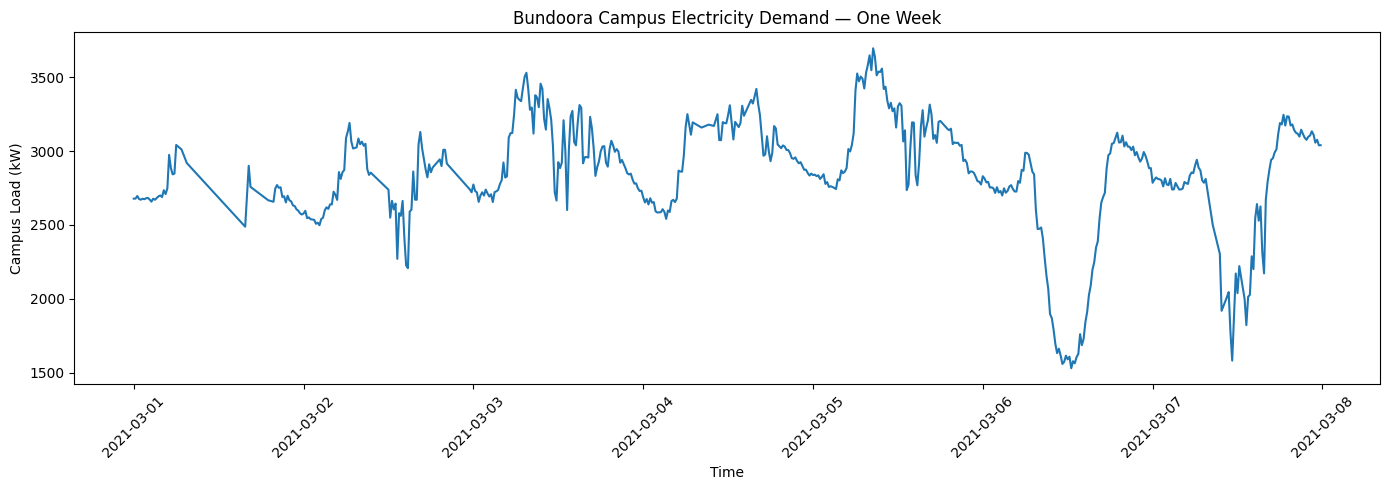

In [ ]:
# Plot a short 2021 sample of Bundoora demand to inspect its time-series behavior.
week = bundoora_load[
    (bundoora_load['timestamp'] >= '2021-03-01') &
    (bundoora_load['timestamp'] < '2021-03-08')
]

plt.figure(figsize=(14, 5))
plt.plot(week['timestamp'], week['Load_kW'])
plt.xlabel('Time')
plt.ylabel('Campus Load (kW)')
plt.title('Bundoora Campus Electricity Demand — One Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Bundoora PV generation and NMI load-PV alignment

The companion UNISOLAR file contains 15-minute `SolarGeneration` measurements in kWh. Bundoora is `CampusKey == 1`. The analysis focuses on 2021, when all 27 selected Bundoora PV sites were active.

`SolarGeneration` represents energy generated during each 15-minute interval. Average PV power is therefore calculated as:

$$
P_{\text{PV}} = \frac{E_{\text{PV}}}{0.25\text{ h}} = 4E_{\text{PV}}.
$$


In [ ]:
# Select the PV installations belonging to the Bundoora campus.
bundoora_pv = solar_data.loc[
    solar_data['CampusKey'] == 1,
    ['CampusKey', 'SiteKey', 'Timestamp', 'SolarGeneration']
].copy()

Distinct Bundoora PV installations are identified, and the number of sites contributing generation data at each timestamp is counted. The results show whether all 27 sites are typically observed together or if partial observations are common.

In [ ]:
# Count the distinct Bundoora PV sites represented at each timestamp
print('Number of sites:', bundoora_pv['SiteKey'].nunique())

pv_availability = (
    bundoora_pv
    .groupby('Timestamp')['SolarGeneration']
    .agg(
        available_sites='count',
        total_generation='sum'
    )
    .reset_index()
)

pv_availability['available_sites'].value_counts().sort_index()

Number of sites: 27


,count
available_sites,
1,6835
2,472
3,7327
4,799
5,103
6,97
7,67
8,54
9,40


In [ ]:
# Determine the observation period covered by each Bundoora PV site.
site_periods = (
    bundoora_pv
    .groupby('SiteKey')
    .agg(
        start=('Timestamp', 'min'),
        end=('Timestamp', 'max'),
        observations=('SolarGeneration', 'count')
    )
    .sort_values('start')
)

site_periods

,start,end,observations
SiteKey,,,
27,2020-01-01 00:15:00,2022-04-23 23:45:00,75621
35,2020-03-16 00:15:00,2022-04-23 23:45:00,69379
34,2020-03-19 00:15:00,2022-04-23 23:45:00,70840
15,2020-06-03 00:15:00,2022-04-23 23:45:00,63984
38,2020-06-11 00:15:00,2022-04-23 23:45:00,63263
37,2020-06-11 00:15:00,2022-04-23 23:45:00,63237
36,2020-06-11 00:15:00,2022-04-23 23:45:00,63154
33,2020-06-11 00:15:00,2022-04-23 23:45:00,63198
32,2020-06-11 00:15:00,2022-04-23 23:45:00,63143


The study focuses on 2021, the common period shared by the UNICON demand data and UNISOLAR PV data, during which all 27 selected Bundoora PV sites are active. Site availability is also evaluated for 2021 to characterize missing-data patterns in the period used for the MPC study.

In [ ]:
# Restrict the Bundoora PV data to the 2021 study period.
pv_2021 = bundoora_pv[
    (bundoora_pv['Timestamp'] >= '2021-01-01') &
    (bundoora_pv['Timestamp'] < '2022-01-01')
].copy()

print('Sites:', pv_2021['SiteKey'].nunique())

pv_availability_2021 = (
    pv_2021
    .groupby('Timestamp')['SolarGeneration']
    .agg(
        available_sites='count',
        total_generation='sum'
    )
    .reset_index()
)

pv_availability_2021['available_sites'].value_counts().sort_index()

Sites: 27


,count
available_sites,
1,15
2,44
3,36
4,30
5,59
6,61
7,42
8,22
9,15


In [ ]:
# Define the expected number of 15-minute observations in a complete non-leap year.
expected_2021 = 365 * 96

print('Expected timestamps:', expected_2021)
print('Observed timestamps:', pv_availability_2021['Timestamp'].nunique())
print(
    'Timestamp coverage:',
    pv_availability_2021['Timestamp'].nunique() / expected_2021 * 100,
    '%'
)

Expected timestamps: 35040
Observed timestamps: 34224
Timestamp coverage: 97.67123287671234 %


In [ ]:
# Keep timestamps where all 27 PV sites are available
pv_complete = pv_availability_2021[
    pv_availability_2021['available_sites'] == 27
].copy()

# SolarGeneration is energy generated during each 15-minute interval (kWh)
# Convert to average power during the interval (kW)
pv_complete['PV_kW'] = pv_complete['total_generation'] * 4

bundoora_pv_2021 = pv_complete[
    ['Timestamp', 'PV_kW']
].copy()

print(bundoora_pv_2021.shape)
bundoora_pv_2021['PV_kW'].describe()

(28804, 2)


,PV_kW
count,28804.000000
mean,262.663838
std,469.049156
min,0.000000
25%,0.000000
50%,0.000000
75%,340.417969
max,1974.973958


In [ ]:
# Confirm that the load and PV timestamps use compatible datetime representations before merging.
print(bundoora_load['timestamp'].dtype)
print(bundoora_pv_2021['Timestamp'].dtype)

print(bundoora_load['timestamp'].head())
print(bundoora_pv_2021['Timestamp'].head())

datetime64[ns]
datetime64[ns]
0   2020-01-01 00:00:00
1   2020-01-01 00:15:00
2   2020-01-01 00:30:00
3   2020-01-01 00:45:00
4   2020-01-01 01:00:00
Name: timestamp, dtype: datetime64[ns]
0   2021-01-01 00:00:00
1   2021-01-01 00:15:00
2   2021-01-01 00:30:00
3   2021-01-01 00:45:00
4   2021-01-01 01:00:00
Name: Timestamp, dtype: datetime64[ns]


The load series is restricted to 2021 so it covers the same calendar period as the selected PV data. The two series are then merged on timestamp to determine how much of the year is represented by both sources.

In [ ]:
# Restrict the preliminary Bundoora load data to the same 2021 study period as the PV data.
load_2021 = bundoora_load[
    (bundoora_load['timestamp'] >= '2021-01-01') &
    (bundoora_load['timestamp'] < '2022-01-01')
].copy()

load_2021 = load_2021.rename(
    columns={'timestamp': 'Timestamp'}
)

merged = pd.merge(
    load_2021,
    bundoora_pv_2021,
    on='Timestamp',
    how='inner'
)

print('Load timestamps:', len(load_2021))
print('PV timestamps:', len(bundoora_pv_2021))
print('Matched timestamps:', len(merged))
print(merged.head())

Load timestamps: 30014
PV timestamps: 28804
Matched timestamps: 24917
            Timestamp   Load_kW  PV_kW
0 2021-01-01 00:00:00  2359.468    0.0
1 2021-01-01 00:15:00  2353.944    0.0
2 2021-01-01 00:30:00  2305.724    0.0
3 2021-01-01 00:45:00  2320.820    0.0
4 2021-01-01 01:00:00  2333.972    0.0


The aligned data are grouped by hour of day to calculate the mean PV generation and mean campus load for each hour. PV output is expected to occur mainly during daylight hours, while demand should reflect campus operating patterns. The comparison is descriptive and does not assume a fixed relationship between the two series.

In [ ]:
# Add hour-of-day information for comparing PV generation with grid demand.
merged['Hour'] = merged['Timestamp'].dt.hour

hourly_profile = (
    merged
    .groupby('Hour')[['PV_kW', 'Load_kW']]
    .mean()
)

hourly_profile

,PV_kW,Load_kW
Hour,,
0,0.000000,2605.125592
1,0.000000,2584.133849
2,0.000000,2575.076417
3,0.000000,2596.153188
4,0.000000,2655.120908
5,0.006612,2754.029949
6,2.617243,3020.329168
7,63.609386,3039.873102
8,323.762526,2785.649514


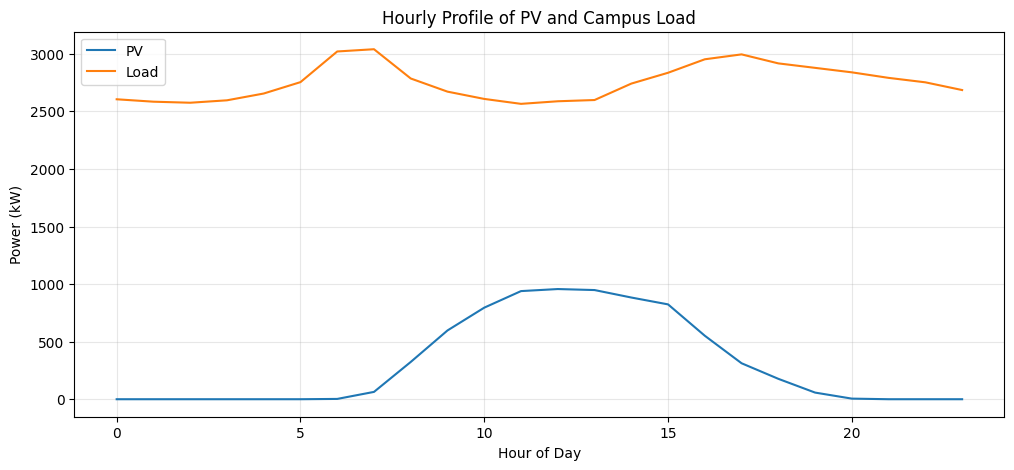

In [ ]:
# Plot hourly profile
plt.figure(figsize=(12, 5))

plt.plot(hourly_profile.index, hourly_profile['PV_kW'], label='PV')
plt.plot(hourly_profile.index, hourly_profile['Load_kW'], label='Load')
plt.xlabel('Hour of Day')
plt.ylabel('Power (kW)')
plt.title('Hourly Profile of PV and Campus Load')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

UNICON does not explicitly state whether the NMI demand series is gross campus demand or net grid demand after behind-the-meter PV. The analysis therefore tests the relationship empirically.

The working modeling assumption is that aggregated NMI demand represents **grid-side demand**. Gross campus load is reconstructed as:

$$
P_{\text{gross}}(t) = P_{\text{grid}}(t) + P_{\text{PV}}(t)
$$

Under no-battery operation this gives:

$$
P_{\text{grid}}(t) = P_{\text{gross}}(t) - P_{\text{PV}}(t)
$$

This interpretation is treated as a modeling assumption rather than an explicitly documented dataset property.

In [ ]:
# Rename the measured NMI demand series to make its grid-side interpretation explicit.
merged = merged.rename(
    columns={'Load_kW': 'Grid_Demand_kW'}
)

merged['Gross_Load_kW'] = (
    merged['Grid_Demand_kW'] + merged['PV_kW']
)

In [ ]:
# Keep only the variables required for the cleaned grid-demand and PV dataset.
merged = merged[
    ['Timestamp', 'Gross_Load_kW', 'PV_kW', 'Grid_Demand_kW']
].sort_values('Timestamp').reset_index(drop=True)

merged.head()

,Timestamp,Gross_Load_kW,PV_kW,Grid_Demand_kW
0,2021-01-01 00:00:00,2359.468,0.0,2359.468
1,2021-01-01 00:15:00,2353.944,0.0,2353.944
2,2021-01-01 00:30:00,2305.724,0.0,2305.724
3,2021-01-01 00:45:00,2320.820,0.0,2320.820
4,2021-01-01 01:00:00,2333.972,0.0,2333.972


Time differences between consecutive observations are calculated to identify gaps in the 15‑minute time series.

In [ ]:
# Calculate the time difference between consecutive observations to identify gaps in the 15-minute series.
merged['Time_Diff'] = merged['Timestamp'].diff()

merged['Time_Diff'].value_counts().sort_index().head(20)

,count
Time_Diff,
0 days 00:15:00,23456
0 days 00:30:00,552
0 days 00:45:00,213
0 days 01:00:00,155
0 days 01:15:00,100
0 days 01:30:00,81
0 days 01:45:00,48
0 days 02:00:00,44
0 days 02:15:00,18


In [ ]:
# Define the expected sampling interval used to identify breaks in continuous operating blocks.
expected_interval = pd.Timedelta(minutes=15)

print('Total observations:', len(merged))

print(
    'Consecutive 15-min transitions:',
    (merged['Time_Diff'] == expected_interval).sum()
)

print(
    'Non-15-min gaps:',
    (merged['Time_Diff'] > expected_interval).sum()
)

print(
    'Longest gap:',
    merged['Time_Diff'].max()
)

Total observations: 24917
Consecutive 15-min transitions: 23456
Non-15-min gaps: 1460
Longest gap: 1 days 16:15:00


Timestamp differences between consecutive observations are calculated to identify gaps in the 15‑minute series. When a gap differs from 15 minutes, the subsequent observation is marked as the start of a new block, and cumulative break flags are used to assign block identifiers. Each block is then summarized by its start time, end time, observation count, and duration. This ensures that the battery simulation does not carry state of charge (SOC) across periods with missing data.

In [ ]:
# Flag timestamps that start a new continuous block because the expected 15-minute interval is broken.
merged['New_Block'] = (
    merged['Time_Diff'].isna() |
    (merged['Time_Diff'] != expected_interval)
)

merged['Block_ID'] = merged['New_Block'].cumsum()

block_summary = (
    merged.groupby('Block_ID')
    .agg(
        Start=('Timestamp', 'min'),
        End=('Timestamp', 'max'),
        Observations=('Timestamp', 'size')
    )
)

block_summary['Duration_hours'] = (
    (block_summary['End'] - block_summary['Start'])
    .dt.total_seconds() / 3600
)

block_summary.sort_values(
    'Observations',
    ascending=False
).head(10)

,Start,End,Observations,Duration_hours
Block_ID,,,,
594,2021-08-15 16:15:00,2021-08-19 09:45:00,359,89.50
439,2021-06-11 12:00:00,2021-06-13 11:45:00,192,47.75
608,2021-08-26 09:15:00,2021-08-28 07:00:00,184,45.75
444,2021-06-15 19:45:00,2021-06-17 16:15:00,179,44.50
595,2021-08-19 11:00:00,2021-08-21 07:00:00,177,44.00
613,2021-08-29 14:15:00,2021-08-31 08:30:00,170,42.25
577,2021-08-05 13:45:00,2021-08-07 06:45:00,165,41.00
1292,2021-12-08 15:15:00,2021-12-10 06:30:00,158,39.25
92,2021-01-28 18:15:00,2021-01-30 06:15:00,145,36.00


## 5. PV missing-data reconstruction

Requiring all 27 PV sites to be present at every timestamp produces excessive fragmentation. Missing PV generation is therefore reconstructed using each site's empirical historical share of total Bundoora generation.

For a timestamp with partial site availability:

$$
\hat{E}_{\text{PV,total}}
=
\frac{E_{\text{PV,observed}}}
{\sum_{i \in \text{available}} s_i},
$$

where $s_i$ is site $i$'s historical generation share estimated from complete daylight observations.

Reconstruction accuracy is validated by deliberately withholding known site combinations. A missing-generation-share threshold is then selected from the validation results rather than from the number of missing sites alone.




Each PV site is placed in its own column on a complete 2021 time grid. This allows missingness to be evaluated by site and by timestamp.


In [ ]:
# Create complete 15-minute grid for every Bundoora PV site
full_time = pd.date_range(
    '2021-01-01',
    '2021-12-31 23:45:00',
    freq='15min'
)

pv_wide = (
    bundoora_pv[
        (bundoora_pv['Timestamp'] >= '2021-01-01') &
        (bundoora_pv['Timestamp'] < '2022-01-01')
    ]
    .pivot(index='Timestamp',
           columns='SiteKey',
           values='SolarGeneration')
    .reindex(full_time)
)

# Missing values per site
pv_missing = pv_wide.isna().sum()

pv_missing.sort_values()

,0
SiteKey,
38,1157
40,1224
18,1230
23,1233
15,1234
24,1241
25,1242
26,1251
19,1252


Missing PV data patterns are evaluated for each site by quantifying total missing observations, the frequency and duration of consecutive missing runs, and the longest gap.

In [ ]:
# Identify consecutive runs of missing values in a single PV site's time series.
# The length of each run tells us whether missing data occur as short gaps
# or as longer periods that may be unsuitable for interpolation/reconstruction.

def missing_run_lengths(series):
    # Create a Boolean series: True where the PV measurement is missing,
    # and False where a valid measurement is available.

    missing = series.isna()

    # Assign a group number whenever the missing/not-missing status changes.
    # Consecutive missing observations therefore receive the same group number,
    # allowing us to measure the length of each continuous missing run.

    groups = (missing != missing.shift()).cumsum()

    # Keep only the missing observations, group consecutive missing observations
    # together, count the number of intervals in each group, and return those
    # run lengths as a list.

    return (
        missing[missing]
        .groupby(groups.loc[missing])
        .size()
        .tolist()
    )


# Store the missing-data statistics for every PV site.

pv_gap_summary = []

# Examine each PV site independently because different sites can have
# different amounts and patterns of missing data.

for site in pv_wide.columns:
    # Find the lengths of all consecutive missing-data runs for this site.

    runs = missing_run_lengths(pv_wide[site])

    # Summarize the amount and structure of missing data for the site.
    # Because the PV data are recorded at 15-minute intervals, the run-length
    # categories also indicate the duration of each missing period:
    # 1 interval = 15 minutes, 2–4 intervals = 30–60 minutes,
    # and more than 4 intervals = more than 1 hour.

    pv_gap_summary.append({
        'SiteKey': site,

        # Total number of 15-minute observations that are missing.
        'Missing_intervals': pv_wide[site].isna().sum(),

        # Number of separate continuous missing periods.
        'Missing_runs': len(runs),

        # Number of isolated missing observations (15-minute gaps).
        'Runs_1_interval': sum(r == 1 for r in runs),

        # Number of missing periods lasting between 30 minutes and 1 hour.
        'Runs_2_to_4': sum(2 <= r <= 4 for r in runs),

        # Number of missing periods lasting longer than 1 hour.
        'Runs_over_4': sum(r > 4 for r in runs),

        # Length of the longest continuous missing period.
        # If the site has no missing observations, return 0 instead of
        # attempting to calculate max([]).
        'Longest_run': max(runs) if runs else 0
    })


# Convert the list of site-level dictionaries into a DataFrame so that
# the missing-data patterns can be compared across all PV sites.
pv_gap_summary = pd.DataFrame(pv_gap_summary)

# Display the resulting missing-data summary for all PV sites.
pv_gap_summary

/tmp/ipykernel_600/2609069841.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .groupby(groups.loc[missing])
/tmp/ipykernel_600/2609069841.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .groupby(groups.loc[missing])
/tmp/ipykernel_600/2609069841.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .groupby(groups.loc[missing])
/tmp/ipykernel_600/2609069841.py:23: FutureWarning: Series.__getitem__ treating keys as positions

,SiteKey,Missing_intervals,Missing_runs,Runs_1_interval,Runs_2_to_4,Runs_over_4,Longest_run
0,14,2079,91,0,20,71,158
1,15,1234,69,0,28,41,158
2,16,1602,165,0,94,71,158
3,17,1268,72,0,27,45,158
4,18,1230,63,0,20,43,158
5,19,1252,65,0,21,44,158
6,20,1443,72,0,22,50,158
7,21,1296,81,0,35,46,158
8,22,1261,74,0,34,40,158
9,23,1233,63,0,18,45,158


In [ ]:
# Number of PV sites missing at every 15-minute timestamp
missing_sites_per_timestamp = pv_wide.isna().sum(axis=1)

missing_sites_per_timestamp.value_counts().sort_index()

,count
0,28804
1,2628
2,1395
3,469
4,176
5,87
6,67
7,63
8,23
9,27


In [ ]:
# Summarize how many PV sites are unavailable at each timestamp.
print(
    'Timestamps with all 27 sites missing:',
    (missing_sites_per_timestamp == 27).sum()
)

print(
    'Timestamps with 1–4 sites missing:',
    missing_sites_per_timestamp.between(1, 4).sum()
)

print(
    'Timestamps with 5–26 sites missing:',
    missing_sites_per_timestamp.between(5, 26).sum()
)

print(
    'Timestamps with no sites missing:',
    (missing_sites_per_timestamp == 0).sum()
)

Timestamps with all 27 sites missing: 816
Timestamps with 1–4 sites missing: 4668
Timestamps with 5–26 sites missing: 752
Timestamps with no sites missing: 28804


Shares are calculated from timestamps where all 27 sites are observed. These are **historical average generation shares**, not installed-capacity shares.


In [ ]:
# Complete observations only
pv_complete_wide = pv_wide.dropna()

# Total generation at each timestamp
complete_total = pv_complete_wide.sum(axis=1)

# Site contribution as fraction of campus total
site_shares = (
    pv_complete_wide
    .div(complete_total.replace(0, float('nan')), axis=0)
    .mean()
)

site_shares = site_shares / site_shares.sum()

site_shares.sort_values(ascending=False)

,0
SiteKey,
27,0.235820
25,0.159592
19,0.082684
18,0.069727
15,0.040055
24,0.036142
33,0.033090
20,0.030901
31,0.028751


The reconstruction assumes that the historical site shares describe the complete 27-site fleet. Their sum should therefore be approximately 1.0, with the difference from 1 only attributable to floating-point rounding.

The largest and smallest shares are also displayed so how unevenly PV generation is distributed across the sites can be seen. A missing site with a large historical share has a much larger effect on the reconstruction than a missing site with a very small share.

In [ ]:
# Verify that the historical generation shares form a complete allocation across the 27 PV sites.
print('Sum of site shares:', site_shares.sum())

print('\nLargest sites:')
display(site_shares.sort_values(ascending=False).head(10))

print('\nSmallest sites:')
display(site_shares.sort_values().head(10))

Sum of site shares: 1.0000000000000002

Largest sites:


,0
SiteKey,
27,0.235820
25,0.159592
19,0.082684
18,0.069727
15,0.040055
24,0.036142
33,0.033090
20,0.030901
31,0.028751



Smallest sites:


,0
SiteKey,
29,0.005014
16,0.005351
28,0.005562
34,0.007687
35,0.010838
39,0.012097
32,0.012306
21,0.013975
30,0.014407


### Validate and apply the reconstruction rule
The validation first withholds one site at a time, then combinations of one to four sites, and relates reconstruction error to the missing historical generation share. The final reconstruction is limited to timestamps with no more than 20% missing share.


In [ ]:
# Only complete timestamps with some PV generation
validation_data = pv_complete_wide[
    pv_complete_wide.sum(axis=1) > 0
].copy()

true_total = validation_data.sum(axis=1)

results = []

for site in validation_data.columns:

    # Pretend this site is missing
    observed_sites = validation_data.columns.drop(site)

    observed_total = validation_data[observed_sites].sum(axis=1)

    # Expected fraction represented by the remaining sites
    available_share = site_shares[observed_sites].sum()

    # Reconstruct total campus PV
    estimated_total = observed_total / available_share

    error = estimated_total - true_total

    results.append({
        'SiteKey': site,
        'Site_share': site_shares[site],
        'MAE_kWh': np.mean(np.abs(error)),
        'RMSE_kWh': np.sqrt(np.mean(error**2)),
        'Mean_true_kWh': true_total.mean(),
        'MAPE_percent': (
            np.mean(
                np.abs(error) / true_total
            ) * 100
        )
    })

validation_results = pd.DataFrame(results)

validation_results.sort_values(
    'MAPE_percent',
    ascending=False
)

,SiteKey,Site_share,MAE_kWh,RMSE_kWh,Mean_true_kWh,MAPE_percent
13,27,0.235820,8.092258,12.475522,161.207048,8.223260
11,25,0.159592,1.506366,2.777203,161.207048,2.080156
5,19,0.082684,0.722529,1.262514,161.207048,0.895396
4,18,0.069727,0.587754,1.023237,161.207048,0.744389
1,15,0.040055,0.596464,0.991074,161.207048,0.673924
26,40,0.028556,0.852286,1.289908,161.207048,0.656247
19,33,0.033090,0.729354,1.113151,161.207048,0.600935
17,31,0.028751,0.718498,1.072217,161.207048,0.583528
10,24,0.036142,0.354837,0.601664,161.207048,0.481867
9,23,0.022124,0.533120,0.837567,161.207048,0.474379


In [ ]:
# Display the reconstruction-validation results for the tested missing-share scenarios.
display(
    validation_results[
        ['MAE_kWh', 'RMSE_kWh', 'MAPE_percent']
    ].describe()
)

print('\nWorst reconstructed sites:')
display(
    validation_results
    .sort_values('MAPE_percent', ascending=False)
    .head(10)
)

,MAE_kWh,RMSE_kWh,MAPE_percent
count,27.000000,27.000000,27.000000
mean,0.716467,1.134137,0.747543
std,1.502392,2.326091,1.540258
min,0.158843,0.237050,0.187374
25%,0.236375,0.372631,0.256362
50%,0.354837,0.574264,0.364654
75%,0.592109,1.007156,0.592231
max,8.092258,12.475522,8.223260



Worst reconstructed sites:


,SiteKey,Site_share,MAE_kWh,RMSE_kWh,Mean_true_kWh,MAPE_percent
13,27,0.235820,8.092258,12.475522,161.207048,8.223260
11,25,0.159592,1.506366,2.777203,161.207048,2.080156
5,19,0.082684,0.722529,1.262514,161.207048,0.895396
4,18,0.069727,0.587754,1.023237,161.207048,0.744389
1,15,0.040055,0.596464,0.991074,161.207048,0.673924
26,40,0.028556,0.852286,1.289908,161.207048,0.656247
19,33,0.033090,0.729354,1.113151,161.207048,0.600935
17,31,0.028751,0.718498,1.072217,161.207048,0.583528
10,24,0.036142,0.354837,0.601664,161.207048,0.481867
9,23,0.022124,0.533120,0.837567,161.207048,0.474379


In [ ]:
# Aggregate absolute reconstruction error and true energy across all validation cases.
all_abs_error = 0
all_true_energy = 0

for site in validation_data.columns:

    observed_sites = validation_data.columns.drop(site)

    observed_total = validation_data[observed_sites].sum(axis=1)

    available_share = site_shares[observed_sites].sum()

    estimated_total = observed_total / available_share

    all_abs_error += np.abs(
        estimated_total - true_total
    ).sum()

    all_true_energy += true_total.sum()

weighted_error_percent = (
    all_abs_error / all_true_energy * 100
)

print(
    'Overall energy-weighted absolute error:',
    weighted_error_percent,
    '%'
)

Overall energy-weighted absolute error: 0.4444388077540406 %


In [ ]:
# Store reconstruction-validation results for each simulated combination of missing PV sites.
combo_results = []

for n_missing in [1, 2, 3, 4]:

    for missing_sites in combinations(validation_data.columns, n_missing):

        missing_sites = list(missing_sites)

        observed_sites = [
            s for s in validation_data.columns
            if s not in missing_sites
        ]

        observed_total = validation_data[observed_sites].sum(axis=1)

        available_share = site_shares[observed_sites].sum()

        estimated_total = observed_total / available_share

        error = estimated_total - true_total

        combo_results.append({
            'N_missing': n_missing,
            'Missing_sites': tuple(missing_sites),
            'Missing_share': site_shares[missing_sites].sum(),
            'MAE_kWh': np.mean(np.abs(error)),
            'RMSE_kWh': np.sqrt(np.mean(error**2)),
            'Weighted_error_percent':
                np.abs(error).sum() / true_total.sum() * 100
        })

combo_results = pd.DataFrame(combo_results)

In [ ]:
# Summarize reconstruction accuracy across all tested missing-site combinations.
combo_summary = (
    combo_results
    .groupby('N_missing')
    ['Weighted_error_percent']
    .agg(
        ['count', 'mean', 'median', 'max']
    )
)

combo_summary

,count,mean,median,max
N_missing,,,,
1,27,0.444439,0.220113,5.019792
2,351,0.806551,0.427978,5.721065
3,2925,1.148850,0.644850,6.320963
4,17550,1.482689,0.839425,6.900016


In [ ]:
# Calculate error percentiles to assess reconstruction performance across different missing-site cases.
percentiles = (
    combo_results
    .groupby('N_missing')['Weighted_error_percent']
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
    .unstack()
)

percentiles.columns = [
    'P50', 'P75', 'P90', 'P95', 'P99'
]

percentiles

,P50,P75,P90,P95,P99
N_missing,,,,,
1,0.220113,0.367297,0.482936,0.812708,3.957598
2,0.427978,0.591352,1.092796,4.940059,5.196599
3,0.644850,0.886833,4.796124,4.988571,5.530981
4,0.839425,1.273261,4.866354,5.130912,5.675985


In [ ]:
# Rank the validation cases by reconstruction error so the acceptable missing-share range can be identified.
combo_results.sort_values(
    'Weighted_error_percent',
    ascending=False
).head(15)

,N_missing,Missing_sites,Missing_share,MAE_kWh,RMSE_kWh,Weighted_error_percent
6754,4,"(15, 19, 25, 27)",0.518151,11.123312,16.694153,6.900016
6544,4,"(15, 18, 25, 27)",0.505195,10.951947,16.506492,6.793715
12089,4,"(18, 19, 25, 27)",0.547823,10.788265,15.999498,6.692180
7524,4,"(15, 24, 25, 27)",0.471610,10.681780,16.142371,6.626125
3484,4,"(14, 15, 25, 27)",0.462562,10.515436,15.937244,6.522938
14189,4,"(19, 24, 25, 27)",0.514238,10.506211,15.655974,6.517216
12859,4,"(18, 24, 25, 27)",0.501281,10.369258,15.547766,6.432261
7666,4,"(15, 25, 27, 37)",0.454593,10.328953,15.648870,6.407259
7643,4,"(15, 25, 26, 27)",0.450618,10.291925,15.634589,6.384290
4454,4,"(14, 19, 25, 27)",0.505191,10.271227,15.403308,6.371450


Missing-site count alone does not capture the importance of a site. Grouping by missing generation share is more physically meaningful because losing a large PV site has a larger effect than losing a small one.

In [ ]:
# Group validation combinations by missing-share ranges
bins = [0, 0.05, 0.10, 0.15, 0.20, 0.30, 1.0]

combo_results['Share_bin'] = pd.cut(
    combo_results['Missing_share'],
    bins=bins,
    right=True
)

share_validation = (
    combo_results
    .groupby('Share_bin', observed=True)
    ['Weighted_error_percent']
    .agg(
        count='count',
        mean='mean',
        median='median',
        max='max'
    )
)

share_validation

,count,mean,median,max
Share_bin,,,,
"(0.0, 0.05]",1300,0.465755,0.468318,0.822090
"(0.05, 0.1]",8585,0.676947,0.657222,1.370527
"(0.1, 0.15]",4369,0.815953,0.808213,1.443391
"(0.15, 0.2]",1356,1.039337,1.055495,1.488932
"(0.2, 0.3]",3615,2.742247,1.602995,5.514334
"(0.3, 1.0]",1628,5.142599,5.174142,6.900016


In [ ]:
# Summarize reconstruction error within each missing-share range.
share_percentiles = (
    combo_results
    .groupby('Share_bin', observed=True)
    ['Weighted_error_percent']
    .quantile([0.90, 0.95, 0.99])
    .unstack()
)

share_percentiles.columns = ['P90', 'P95', 'P99']

share_percentiles

,P90,P95,P99
Share_bin,,,
"(0.0, 0.05]",0.615594,0.654797,0.725829
"(0.05, 0.1]",0.903224,0.984232,1.117736
"(0.1, 0.15]",1.018345,1.087705,1.215513
"(0.15, 0.2]",1.253582,1.306553,1.390728
"(0.2, 0.3]",4.940815,5.012967,5.309921
"(0.3, 1.0]",5.719374,5.940191,6.287188




The validation shows that reconstruction error increases as a larger proportion of the historical PV generation share becomes unavailable. The increase becomes particularly pronounced once the missing generation share exceeds 20%.

For timestamps with 15–20% missing share, the mean reconstruction error is 1.04%, with a 95th-percentile error of 1.31%. In comparison, timestamps with 20–30% missing share have a mean error of 2.74% and a 95th-percentile error of 5.01%. The higher missing-share ranges show further deterioration.

Based on this validation, a **20% maximum missing-share threshold** is used for the final PV reconstruction. This means that reconstruction is permitted only when at least 80% of the historical generation share remains represented by observed PV sites. Timestamps with more than 20% missing share are left unreconstructed because the validation indicates substantially greater estimation error in this region.

The 20% value is therefore a data-driven quality-control threshold based on the observed relationship between missing generation share and reconstruction error, rather than an arbitrary assumption.

### Reconstruct partially observed PV timestamps

Observed site generation is scaled by the historical share represented by the available sites. Reconstruction is allowed only when the missing-share threshold validated above is satisfied.


In [ ]:
# Sum measured generation at each timestamp
observed_generation = pv_wide.sum(axis=1, skipna=True)

# Calculate expected generation share represented by available sites
available_share = pv_wide.notna().mul(
    site_shares,
    axis=1
).sum(axis=1)

missing_share = 1 - available_share

# Reconstruct campus generation only where:
# 1. at least one site is available
# 2. missing expected generation share <= 20%
can_reconstruct = (
    (available_share > 0) &
    (missing_share <= 0.20)
)

pv_reconstructed = pd.Series(
    np.nan,
    index=pv_wide.index,
    name='PV_kWh'
)

pv_reconstructed.loc[can_reconstruct] = (
    observed_generation.loc[can_reconstruct] /
    available_share.loc[can_reconstruct]
)

In [ ]:
# Compare timestamps with complete PV measurements against timestamps requiring reconstruction.
original_complete = pv_wide.notna().all(axis=1)

print(
    'Original complete timestamps:',
    original_complete.sum()
)

print(
    'Reconstructed/usable timestamps:',
    pv_reconstructed.notna().sum()
)

print(
    'Additional timestamps recovered:',
    (
        pv_reconstructed.notna() &
        ~original_complete
    ).sum()
)

print(
    'Still missing:',
    pv_reconstructed.isna().sum()
)

print(
    'Coverage:',
    pv_reconstructed.notna().mean() * 100,
    '%'
)

Original complete timestamps: 28804
Reconstructed/usable timestamps: 31502
Additional timestamps recovered: 2698
Still missing: 3538
Coverage: 89.90296803652969 %


The reconstruction increases the number of usable PV timestamps while retaining the validation-based missing-share limit. The reconstructed series is then converted to kW and merged with the cleaned grid-demand data.

In [ ]:
# Build the cleaned Bundoora PV series using the validated historical-share reconstruction rule.
bundoora_pv_clean = (
    pv_reconstructed
    .rename('PV_kWh')
    .reset_index()
    .rename(columns={'index': 'Timestamp'})
)

bundoora_pv_clean['PV_kW'] = (
    bundoora_pv_clean['PV_kWh'] * 4
)

bundoora_pv_clean.head()

,Timestamp,PV_kWh,PV_kW
0,2021-01-01 00:00:00,0.0,0.0
1,2021-01-01 00:15:00,0.0,0.0
2,2021-01-01 00:30:00,0.0,0.0
3,2021-01-01 00:45:00,0.0,0.0
4,2021-01-01 01:00:00,0.0,0.0


### Merge reconstructed PV with cleaned demand

Only PV timestamps that pass the reconstruction criteria are retained. They are then merged with cleaned campus demand so the controller receives aligned load and PV inputs.


In [ ]:
# Keep usable reconstructed PV observations
pv_for_merge = bundoora_pv_clean[
    bundoora_pv_clean['PV_kW'].notna()
].copy()

# Merge with the cleaned NMI data
merged_clean = pd.merge(
    load_2021,
    pv_for_merge[['Timestamp', 'PV_kW']],
    on='Timestamp',
    how='inner'
)

merged_clean = merged_clean.sort_values(
    'Timestamp'
).reset_index(drop=True)

print('Merged observations:', len(merged_clean))

Merged observations: 27080


In [ ]:
# Standardize the cleaned merged load column name before final continuity checks.
merged_clean = merged_clean.rename(
    columns={'Load_kW': 'Grid_Demand_kW'}
)

merged_clean['Gross_Load_kW'] = (
    merged_clean['Grid_Demand_kW'] +
    merged_clean['PV_kW']
)

In [ ]:
# Calculate timestamp gaps in the cleaned merged dataset.
merged_clean['Time_Diff'] = (
    merged_clean['Timestamp'].diff()
)

expected_interval = pd.Timedelta(minutes=15)

print(
    'Consecutive 15-min transitions:',
    (merged_clean['Time_Diff'] == expected_interval).sum()
)

print(
    'Non-15-min gaps:',
    (merged_clean['Time_Diff'] > expected_interval).sum()
)

print(
    'Longest gap:',
    merged_clean['Time_Diff'].max()
)

Consecutive 15-min transitions: 25550
Non-15-min gaps: 1529
Longest gap: 1 days 15:45:00


In [ ]:
# Identify continuous operating blocks in the cleaned merged dataset.
merged_clean['New_Block'] = (
    merged_clean['Time_Diff'].isna() |
    (merged_clean['Time_Diff'] != expected_interval)
)

merged_clean['Block_ID'] = (
    merged_clean['New_Block'].cumsum()
)

block_summary_clean = (
    merged_clean
    .groupby('Block_ID')
    .agg(
        Start=('Timestamp', 'min'),
        End=('Timestamp', 'max'),
        Observations=('Timestamp', 'size')
    )
)

block_summary_clean['Duration_hours'] = (
    (
        block_summary_clean['End'] -
        block_summary_clean['Start']
    ).dt.total_seconds() / 3600
)

block_summary_clean.sort_values(
    'Observations',
    ascending=False
).head(10)

,Start,End,Observations,Duration_hours
Block_ID,,,,
621,2021-08-15 16:15:00,2021-08-22 08:30:00,642,160.25
463,2021-06-07 19:45:00,2021-06-13 11:45:00,545,136.00
539,2021-07-02 19:15:00,2021-07-07 06:45:00,431,107.50
260,2021-03-08 20:45:00,2021-03-12 11:30:00,348,86.75
283,2021-03-16 14:15:00,2021-03-19 18:15:00,305,76.00
1338,2021-12-08 14:30:00,2021-12-11 13:00:00,283,70.50
635,2021-08-29 14:15:00,2021-09-01 06:45:00,259,64.50
617,2021-08-12 00:15:00,2021-08-14 07:00:00,220,54.75
632,2021-08-26 09:15:00,2021-08-28 09:30:00,194,48.25


## 6. Final Bundoora NMI cleaning

The final load construction uses all seven Bundoora NMI series on a complete 2021 15-minute grid. Missingness is treated according to meter size and gap duration:

- NMIs 5, 7, 9, 13, and 14: missing values are filled from a median profile indexed by weekday/weekend and 15-minute time slot. This method is validated against observed values before use.
- NMI 12: only the short internal gap is time-interpolated, with a maximum of four consecutive intervals.
- NMI 1: interpolation is accepted only for original missing runs of four intervals or fewer; longer gaps remain missing.

Campus grid demand is summed only at timestamps where all seven cleaned NMI values are available.


In [ ]:
# Select the seven Bundoora NMI meters for the 2021 cleaning procedure.
bundoora_nmi_2021 = demand_15min[
    (demand_15min['campus_id'] == 1) &
    (demand_15min['timestamp'] >= '2021-01-01') &
    (demand_15min['timestamp'] < '2022-01-01')
].copy()

nmi_wide_2021 = (
    bundoora_nmi_2021
    .pivot(
        index='timestamp',
        columns='meter_id',
        values='demand_kW'
    )
    .reindex(
        pd.date_range(
            '2021-01-01',
            '2021-12-31 23:45:00',
            freq='15min'
        )
    )
)

missing_nmis = nmi_wide_2021.isna().sum(axis=1)

missing_nmis.value_counts().sort_index()

,count
0,30014
1,4394
2,561
3,70
4,1


In [ ]:
# Report the number of complete Bundoora NMI timestamps available before missing-value treatment.
print(
    'Complete timestamps:',
    (missing_nmis == 0).sum()
)

print(
    'Only 1 NMI missing:',
    (missing_nmis == 1).sum()
)

print(
    '2 NMIs missing:',
    (missing_nmis == 2).sum()
)

print(
    '3+ NMIs missing:',
    (missing_nmis >= 3).sum()
)

print(
    'All 7 NMIs missing:',
    (missing_nmis == 7).sum()
)

Complete timestamps: 30014
Only 1 NMI missing: 4394
2 NMIs missing: 561
3+ NMIs missing: 71
All 7 NMIs missing: 0


In [ ]:
# Summarize missing intervals for each Bundoora NMI meter.
nmi_missing_summary = pd.DataFrame({
    'Missing_intervals': nmi_wide_2021.isna().sum(),
    'Mean_kW': nmi_wide_2021.mean()
})

nmi_missing_summary['Mean_share_percent'] = (
    nmi_missing_summary['Mean_kW'] /
    nmi_missing_summary['Mean_kW'].sum() * 100
)

nmi_missing_summary.sort_values(
    'Mean_share_percent',
    ascending=False
)

,Missing_intervals,Mean_kW,Mean_share_percent
meter_id,,,
12,4,1951.065948,71.689081
1,993,627.714042,23.064440
5,175,46.857720,1.721719
14,125,37.435745,1.375522
9,1872,22.994534,0.844901
13,1123,20.579477,0.756163
7,1438,14.918933,0.548174


In [ ]:
# Identify timestamps where exactly one NMI meter is missing, useful for targeted gap analysis.
one_missing = nmi_wide_2021[
    nmi_wide_2021.isna().sum(axis=1) == 1
]

missing_meter_counts = (
    one_missing
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_meter_counts

,0
meter_id,
9,1513
7,1238
1,701
13,682
5,150
14,107
12,3


In [ ]:
# Calculate consecutive missing-run lengths for each NMI so interpolation rules can be applied consistently.
def missing_run_lengths(series):
    missing = series.isna()
    groups = (missing != missing.shift()).cumsum()

    return (
        missing[missing]
        .groupby(groups.loc[missing])
        .size()
        .tolist()
    )

nmi_gap_summary = []

for meter in nmi_wide_2021.columns:
    runs = missing_run_lengths(nmi_wide_2021[meter])

    nmi_gap_summary.append({
        'NMI': meter,
        'Missing_intervals': nmi_wide_2021[meter].isna().sum(),
        'Missing_runs': len(runs),
        'Runs_1_interval': sum(r == 1 for r in runs),
        'Runs_2_to_4': sum(2 <= r <= 4 for r in runs),
        'Runs_5_to_16': sum(5 <= r <= 16 for r in runs),
        'Runs_over_16': sum(r > 16 for r in runs),
        'Longest_run': max(runs) if runs else 0,
        'Longest_hours': max(runs) * 0.25 if runs else 0
    })

nmi_gap_summary = pd.DataFrame(nmi_gap_summary)

nmi_gap_summary

/tmp/ipykernel_600/2024343808.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .groupby(groups.loc[missing])
/tmp/ipykernel_600/2024343808.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .groupby(groups.loc[missing])
/tmp/ipykernel_600/2024343808.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .groupby(groups.loc[missing])
/tmp/ipykernel_600/2024343808.py:8: FutureWarning: Series.__getitem__ treating keys as positions is 

,NMI,Missing_intervals,Missing_runs,Runs_1_interval,Runs_2_to_4,Runs_5_to_16,Runs_over_16,Longest_run,Longest_hours
0,1,993,226,87,71,61,7,33,8.25
1,5,175,82,59,10,13,0,13,3.25
2,7,1438,623,341,213,68,1,33,8.25
3,9,1872,919,468,388,62,1,17,4.25
4,12,4,1,0,1,0,0,4,1.00
5,13,1123,231,100,74,37,20,42,10.50
6,14,125,36,13,18,3,2,22,5.50


### Build meter-specific temporal profiles

Weekday/weekend status and 15-minute time-of-day are used to build representative profiles for the smaller NMIs. This preserves recurring demand patterns without assuming one meter follows another meter’s share.


In [ ]:
# Add time-of-day and day-type identifiers
nmi_validation = nmi_wide_2021.copy()

time_slot = (
    nmi_validation.index.hour * 4 +
    nmi_validation.index.minute // 15
)

day_type = np.where(
    nmi_validation.index.dayofweek < 5,
    'weekday',
    'weekend'
)

profile_validation = []

small_nmis = [5, 7, 9, 13, 14]

for meter in small_nmis:

    df = pd.DataFrame({
        'Actual': nmi_validation[meter],
        'TimeSlot': time_slot,
        'DayType': day_type
    })

    # Typical demand for each 15-minute slot and day type
    profile = (
        df.dropna()
        .groupby(['DayType', 'TimeSlot'])['Actual']
        .median()
    )

    # Predict every available observation from its profile
    predicted = [
        profile.get((d, t), np.nan)
        for d, t in zip(df['DayType'], df['TimeSlot'])
    ]

    df['Predicted'] = predicted

    valid = df[['Actual', 'Predicted']].dropna()

    mae = (
        valid['Actual'] - valid['Predicted']
    ).abs().mean()

    rmse = np.sqrt(
        ((valid['Actual'] - valid['Predicted']) ** 2).mean()
    )

    normalized_mae = (
        mae / valid['Actual'].mean() * 100
    )

    profile_validation.append({
        'NMI': meter,
        'Mean_kW': valid['Actual'].mean(),
        'MAE_kW': mae,
        'RMSE_kW': rmse,
        'Normalized_MAE_percent': normalized_mae
    })

profile_validation = pd.DataFrame(profile_validation)

profile_validation

,NMI,Mean_kW,MAE_kW,RMSE_kW,Normalized_MAE_percent
0,5,46.857720,7.513805,10.436365,16.035362
1,7,14.918933,1.870821,2.816272,12.539912
2,9,22.994534,5.345889,8.011882,23.248520
3,13,20.579477,5.504935,7.940776,26.749635
4,14,37.435745,11.741491,15.141686,31.364384


In [ ]:
# Create a working copy of the NMI series before applying meter-specific missing-value rules.
nmi_clean = nmi_wide_2021.copy()

small_nmis = [5, 7, 9, 13, 14]

time_slot = (
    nmi_clean.index.hour * 4 +
    nmi_clean.index.minute // 15
)

day_type = pd.Series(
    np.where(
        nmi_clean.index.dayofweek < 5,
        'weekday',
        'weekend'
    ),
    index=nmi_clean.index
)

for meter in small_nmis:

    profile_df = pd.DataFrame({
        'Demand': nmi_clean[meter],
        'TimeSlot': time_slot,
        'DayType': day_type
    })

    profile = (
        profile_df
        .dropna()
        .groupby(['DayType', 'TimeSlot'])['Demand']
        .median()
    )

    missing = nmi_clean[meter].isna()

    estimates = [
        profile.get((day_type.loc[t], time_slot[i]), np.nan)
        for i, t in enumerate(nmi_clean.index)
    ]

    estimates = pd.Series(
        estimates,
        index=nmi_clean.index
    )

    nmi_clean.loc[missing, meter] = estimates.loc[missing]

In [ ]:
# Fill the short one-hour NMI 12 gap using time-based interpolation.
nmi_clean[12] = nmi_clean[12].interpolate(
    method='time',
    limit=4,
    limit_area='inside'
)

In [ ]:
# Interpolate only short missing runs in NMI 1 while preserving longer unresolved gaps.
nmi1_interp = nmi_clean[1].interpolate(
    method='time',
    limit=4,
    limit_area='inside'
)

# Identify original missing runs
missing = nmi_clean[1].isna()
groups = (missing != missing.shift()).cumsum()

run_sizes = (
    missing.groupby(groups).transform('sum')
)

# Only accept interpolation for gaps <= 4 intervals
fill_mask = missing & (run_sizes <= 4)

nmi_clean.loc[fill_mask, 1] = nmi1_interp.loc[fill_mask]

/tmp/ipykernel_600/706028064.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  missing.groupby(groups).transform("sum")


In [ ]:
# Check the remaining missing values after applying the NMI cleaning rules.
print('Remaining missing values by NMI:')
display(nmi_clean.isna().sum())

complete_after_cleaning = nmi_clean.notna().all(axis=1)

print(
    '\nComplete campus timestamps:',
    complete_after_cleaning.sum()
)

print(
    'Coverage:',
    complete_after_cleaning.mean() * 100,
    '%'
)

Remaining missing values by NMI:


,0
meter_id,
1,711
5,0
7,0
9,0
12,0
13,0
14,0



Complete campus timestamps: 34329
Coverage: 97.9708904109589 %


The remaining missing values determine which timestamps can be used in the final campus aggregation. Longer unresolved gaps are not filled simply to increase coverage because doing so would introduce unsupported assumptions about campus demand.

In [ ]:
# Keep timestamps where all seven NMIs are available after cleaning
nmi_complete = nmi_clean.dropna().copy()

# Aggregate the seven NMIs
nmi_complete['Grid_Demand_kW'] = nmi_complete.sum(axis=1)

bundoora_load_clean = (
    nmi_complete[['Grid_Demand_kW']]
    .reset_index()
    .rename(columns={'index': 'Timestamp'})
)

print('Final load observations:', len(bundoora_load_clean))
bundoora_load_clean.head()

Final load observations: 34329


meter_id,Timestamp,Grid_Demand_kW
0,2021-01-01 00:00:00,2359.468
1,2021-01-01 00:15:00,2353.944
2,2021-01-01 00:30:00,2305.724
3,2021-01-01 00:45:00,2320.820
4,2021-01-01 01:00:00,2333.972


## 7. Merge load and PV and reconstruct gross demand

The cleaned NMI total is treated as measured grid demand. Reconstructed PV is added to it to estimate gross campus electrical demand:

$$P_{\mathrm{gross},t}=P_{\mathrm{grid},t}+P_{\mathrm{PV},t}.$$

The resulting data are not fully continuous because conservative cleaning leaves unresolved gaps. Later control simulations therefore operate on independent continuous 15-minute blocks, resetting the battery to its initial SOC at the beginning of each block.


In [ ]:
# Align the relevant time series on common timestamps.
final_data = pd.merge(
    bundoora_load_clean,
    bundoora_pv_clean[
        ['Timestamp', 'PV_kW']
    ].dropna(),
    on='Timestamp',
    how='inner'
)

final_data = final_data.sort_values(
    'Timestamp'
).reset_index(drop=True)

# Reconstruct gross campus electrical demand
final_data['Gross_Load_kW'] = (
    final_data['Grid_Demand_kW'] +
    final_data['PV_kW']
)

print('Final matched observations:', len(final_data))
print(
    'Final coverage:',
    len(final_data) / 35040 * 100,
    '%'
)

final_data.head()

Final matched observations: 30875
Final coverage: 88.11358447488584 %


,Timestamp,Grid_Demand_kW,PV_kW,Gross_Load_kW
0,2021-01-01 00:00:00,2359.468,0.0,2359.468
1,2021-01-01 00:15:00,2353.944,0.0,2353.944
2,2021-01-01 00:30:00,2305.724,0.0,2305.724
3,2021-01-01 00:45:00,2320.820,0.0,2320.820
4,2021-01-01 01:00:00,2333.972,0.0,2333.972


### Validate the final merged time series

The final load-PV merge is the dataset passed to MPC, so its timestamp continuity is checked once more. This ensures later controller results are based on known 15-minute transitions.


In [ ]:
# Recalculate timestamp gaps after the final load-PV merge.
final_data['Time_Diff'] = final_data['Timestamp'].diff()

expected_interval = pd.Timedelta(minutes=15)

print(
    'Consecutive 15-min transitions:',
    (final_data['Time_Diff'] == expected_interval).sum()
)

print(
    'Non-15-min gaps:',
    (final_data['Time_Diff'] > expected_interval).sum()
)

print(
    'Longest gap:',
    final_data['Time_Diff'].max()
)

# Identify continuous blocks
final_data['New_Block'] = (
    final_data['Time_Diff'].isna() |
    (final_data['Time_Diff'] != expected_interval)
)

final_data['Block_ID'] = final_data['New_Block'].cumsum()

block_summary_final = (
    final_data
    .groupby('Block_ID')
    .agg(
        Start=('Timestamp', 'min'),
        End=('Timestamp', 'max'),
        Observations=('Timestamp', 'size')
    )
)

block_summary_final['Duration_hours'] = (
    (
        block_summary_final['End'] -
        block_summary_final['Start']
    ).dt.total_seconds() / 3600
)

block_summary_final.sort_values(
    'Observations',
    ascending=False
).head(10)

Consecutive 15-min transitions: 30680
Non-15-min gaps: 194
Longest gap: 1 days 15:45:00


,Start,End,Observations,Duration_hours
Block_ID,,,,
151,2021-08-12 00:15:00,2021-09-16 09:00:00,3396,848.75
145,2021-07-15 18:45:00,2021-07-28 17:15:00,1243,310.50
179,2021-11-30 06:30:00,2021-12-12 11:45:00,1174,293.25
155,2021-10-03 03:15:00,2021-10-12 10:45:00,895,223.50
171,2021-11-09 13:30:00,2021-11-17 11:45:00,762,190.25
129,2021-06-07 19:45:00,2021-06-15 17:00:00,758,189.25
127,2021-05-29 15:45:00,2021-06-05 17:30:00,680,169.75
170,2021-11-02 14:15:00,2021-11-09 12:30:00,666,166.25
40,2021-03-16 09:15:00,2021-03-23 07:30:00,666,166.25


In [ ]:
# Keep the variables required by the MPC model and downstream controller analysis.
mpc_data = final_data[
    [
        'Timestamp',
        'Grid_Demand_kW',
        'PV_kW',
        'Gross_Load_kW'
    ]
].copy()

print(mpc_data.shape)
mpc_data.head()

(30875, 4)


,Timestamp,Grid_Demand_kW,PV_kW,Gross_Load_kW
0,2021-01-01 00:00:00,2359.468,0.0,2359.468
1,2021-01-01 00:15:00,2353.944,0.0,2353.944
2,2021-01-01 00:30:00,2305.724,0.0,2305.724
3,2021-01-01 00:45:00,2320.820,0.0,2320.820
4,2021-01-01 01:00:00,2333.972,0.0,2333.972


In [ ]:
# Calculate descriptive statistics for grid demand, PV generation, and gross load.
system_stats = mpc_data[
    [
        'Grid_Demand_kW',
        'PV_kW',
        'Gross_Load_kW'
    ]
].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
)

system_stats

,Grid_Demand_kW,PV_kW,Gross_Load_kW
count,30875.000000,30875.000000,30875.000000
mean,2714.855765,293.972789,3008.828554
std,473.987205,489.343477,539.453148
min,823.356000,0.000000,1192.444646
5%,1821.439900,0.000000,2383.726800
25%,2499.666500,0.000000,2631.376000
50%,2706.844000,0.000000,2847.744000
75%,2964.258000,428.023437,3327.190062
95%,3517.387333,1485.153125,4025.953737
max,4572.367667,1974.973958,6179.091062


### Calculate demand thresholds and the amount of peak-shaving power they would require


For each selected percentile, the corresponding grid-demand threshold is identified, and the maximum exceedance above that threshold is calculated. For example, if the 95th-percentile threshold is 3,500 kW and the observed peak demand reaches 4,500 kW, the required battery discharge power at that instant would be 1,000 kW to limit grid demand to 3,500 kW. This provides a preliminary battery power-sizing assessment and does not account for battery state of charge (SOC) or energy availability over time.

In [ ]:
# Convert the 15-minute power observations into total energy over the usable dataset.
total_load_energy = (
    mpc_data['Gross_Load_kW'].sum() * 0.25
)

total_pv_energy = (
    mpc_data['PV_kW'].sum() * 0.25
)

print(
    'Gross load energy:',
    total_load_energy / 1000,
    'MWh'
)

print(
    'PV generation:',
    total_pv_energy / 1000,
    'MWh'
)

print(
    'PV / gross load:',
    total_pv_energy / total_load_energy * 100,
    '%'
)

print(
    'Maximum PV:',
    mpc_data['PV_kW'].max(),
    'kW'
)

print(
    'Maximum gross load:',
    mpc_data['Gross_Load_kW'].max(),
    'kW'
)

Gross load energy: 23224.395401301586 MWh
PV generation: 2269.1024617599182 MWh
PV / gross load: 9.770340293262269 %
Maximum PV: 1974.973958333333 kW
Maximum gross load: 6179.0910625 kW


In [ ]:
# Determine the baseline 95th-percentile grid-demand threshold used for peak-shaving analysis.
threshold = np.percentile(
    mpc_data['Grid_Demand_kW'],
    95
)

peak_data = mpc_data[
    ['Timestamp', 'Grid_Demand_kW']
].copy()

peak_data['Required_Discharge_kW'] = np.maximum(
    peak_data['Grid_Demand_kW'] - threshold,
    0
)

peak_data['Above_Threshold'] = (
    peak_data['Required_Discharge_kW'] > 0
)

# New peak event whenever:
# 1. demand moves from below threshold to above threshold, or
# 2. timestamps are not consecutive
time_gap = (
    peak_data['Timestamp'].diff()
    != pd.Timedelta(minutes=15)
)

new_event = (
    peak_data['Above_Threshold']
    &
    (
        ~peak_data['Above_Threshold'].shift(
            fill_value=False
        )
        | time_gap
    )
)

peak_data['Event_ID'] = new_event.cumsum()

peak_events = (
    peak_data[
        peak_data['Above_Threshold']
    ]
    .groupby('Event_ID')
    .agg(
        Start=('Timestamp', 'min'),
        End=('Timestamp', 'max'),
        Intervals=('Timestamp', 'size'),
        Peak_Discharge_kW=(
            'Required_Discharge_kW',
            'max'
        ),
        Energy_Required_kWh=(
            'Required_Discharge_kW',
            lambda x: x.sum() * 0.25
        )
    )
)

peak_events['Duration_hours'] = (
    peak_events['Intervals'] * 0.25
)

peak_events.describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

,Start,End,Intervals,Peak_Discharge_kW,Energy_Required_kWh,Duration_hours
count,332,332,332.000000,332.000000,332.000000,332.000000
mean,2021-05-30 23:14:43.734939904,2021-05-31 00:09:29.277108736,4.650602,183.360493,210.094350,1.162651
min,2021-01-25 08:15:00,2021-01-25 08:15:00,1.000000,0.312667,0.078167,0.250000
50%,2021-06-04 00:07:30,2021-06-04 01:22:30,3.000000,118.656667,50.157667,0.750000
75%,2021-07-13 07:07:30,2021-07-13 07:15:00,6.000000,278.244667,233.720750,1.500000
90%,2021-08-06 03:13:30,2021-08-06 03:54:00,12.000000,431.360267,576.528167,3.000000
95%,2021-09-24 08:58:30,2021-09-24 09:06:45,16.000000,560.211517,947.331729,4.000000
99%,2021-12-02 13:41:24,2021-12-02 15:08:51,21.000000,782.438557,1611.231318,5.250000
max,2021-12-13 15:30:00,2021-12-13 16:30:00,26.000000,1054.980333,2408.969167,6.500000
std,NaN,NaN,4.953399,186.615214,361.743753,1.238350


## 8. BESS sizing and parameter selection

Battery **power and energy ratings are derived from the Bundoora demand profile**, rather than copied from a reference system. The analysis first asks how much discharge power would be required to cap demand at selected upper percentiles, then groups consecutive exceedances above the 95th-percentile threshold into peak events and calculates their energy requirements.

A representative **1 MW / 2 MWh lithium-ion BESS** is selected. This is a study configuration, not an economic optimum. The 1 MW rating is close to the maximum discharge required above the 95th-percentile demand threshold, while 2 MWh provides 1.2 MWh of stored-energy range between 20% and 80% SOC before accounting for discharge losses, covering approximately the 95th-percentile peak-event energy requirement without sizing to the most extreme event.


In [ ]:
# Extract the baseline grid-demand series for percentile and peak-demand analysis.
grid = mpc_data['Grid_Demand_kW']

percentiles = [90, 95, 97.5, 99]

for p in percentiles:
    threshold = np.percentile(grid, p)

    required_power = np.maximum(
        grid - threshold,
        0
    )

    print(
        f'{p}th percentile threshold:'
        f' {threshold:.1f} kW | '
        f'Maximum required BESS power:'
        f' {required_power.max():.1f} kW'
    )

90th percentile threshold: 3318.6 kW | Maximum required BESS power: 1253.8 kW
95th percentile threshold: 3517.4 kW | Maximum required BESS power: 1055.0 kW
97.5th percentile threshold: 3659.0 kW | Maximum required BESS power: 913.4 kW
99th percentile threshold: 3802.0 kW | Maximum required BESS power: 770.4 kW


### Estimate the energy required to shave individual high-demand events

Peak-shaving capability depends not only on battery power but also on available energy. While short peaks may require only brief battery discharge, sustained periods of high demand can consume a significant amount of stored energy.

High-demand events are identified relative to the selected demand threshold, and the cumulative energy required to reduce each event to that threshold is calculated. Comparing the resulting distribution of event energy requirements with the battery's usable energy capacity helps assess how effectively different events can be shaved and supports the use of a representative 2 MWh battery rather than sizing the system for the most extreme event.

In [ ]:
# Calculate demand thresholds at several percentiles to identify high-demand operating levels.
for p in percentiles:
    threshold = np.percentile(grid, p)

    exceedance = grid > threshold

    print(
        f'{p}th percentile | '
        f'Threshold = {threshold:.1f} kW | '
        f'Intervals above = {exceedance.sum()} | '
        f'Hours above = {exceedance.sum() * 0.25:.1f}'
    )

90th percentile | Threshold = 3318.6 kW | Intervals above = 3088 | Hours above = 772.0
95th percentile | Threshold = 3517.4 kW | Intervals above = 1544 | Hours above = 386.0
97.5th percentile | Threshold = 3659.0 kW | Intervals above = 772 | Hours above = 193.0
99th percentile | Threshold = 3802.0 kW | Intervals above = 309 | Hours above = 77.2


In [ ]:
# Determine the baseline 95th-percentile grid-demand threshold used for peak-shaving analysis.
threshold = np.percentile(
    mpc_data['Grid_Demand_kW'],
    95
)

peak_data = mpc_data[
    ['Timestamp', 'Grid_Demand_kW']
].copy()

peak_data['Required_Discharge_kW'] = np.maximum(
    peak_data['Grid_Demand_kW'] - threshold,
    0
)

peak_data['Above_Threshold'] = (
    peak_data['Required_Discharge_kW'] > 0
)

# New peak event whenever:
# 1. demand moves from below threshold to above threshold, or
# 2. timestamps are not consecutive
time_gap = (
    peak_data['Timestamp'].diff()
    != pd.Timedelta(minutes=15)
)

new_event = (
    peak_data['Above_Threshold']
    &
    (
        ~peak_data['Above_Threshold'].shift(
            fill_value=False
        )
        | time_gap
    )
)

peak_data['Event_ID'] = new_event.cumsum()

peak_events = (
    peak_data[
        peak_data['Above_Threshold']
    ]
    .groupby('Event_ID')
    .agg(
        Start=('Timestamp', 'min'),
        End=('Timestamp', 'max'),
        Intervals=('Timestamp', 'size'),
        Peak_Discharge_kW=(
            'Required_Discharge_kW',
            'max'
        ),
        Energy_Required_kWh=(
            'Required_Discharge_kW',
            lambda x: x.sum() * 0.25
        )
    )
)

peak_events['Duration_hours'] = (
    peak_events['Intervals'] * 0.25
)

peak_events.describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

,Start,End,Intervals,Peak_Discharge_kW,Energy_Required_kWh,Duration_hours
count,332,332,332.000000,332.000000,332.000000,332.000000
mean,2021-05-30 23:14:43.734939904,2021-05-31 00:09:29.277108736,4.650602,183.360493,210.094350,1.162651
min,2021-01-25 08:15:00,2021-01-25 08:15:00,1.000000,0.312667,0.078167,0.250000
50%,2021-06-04 00:07:30,2021-06-04 01:22:30,3.000000,118.656667,50.157667,0.750000
75%,2021-07-13 07:07:30,2021-07-13 07:15:00,6.000000,278.244667,233.720750,1.500000
90%,2021-08-06 03:13:30,2021-08-06 03:54:00,12.000000,431.360267,576.528167,3.000000
95%,2021-09-24 08:58:30,2021-09-24 09:06:45,16.000000,560.211517,947.331729,4.000000
99%,2021-12-02 13:41:24,2021-12-02 15:08:51,21.000000,782.438557,1611.231318,5.250000
max,2021-12-13 15:30:00,2021-12-13 16:30:00,26.000000,1054.980333,2408.969167,6.500000
std,NaN,NaN,4.953399,186.615214,361.743753,1.238350


In [ ]:
# Identify high-demand events and estimate the battery energy required to shave each event.
peak_events.sort_values(
    'Energy_Required_kWh',
    ascending=False
).head(15)

,Start,End,Intervals,Peak_Discharge_kW,Energy_Required_kWh,Duration_hours
Event_ID,,,,,,
18,2021-02-11 12:45:00,2021-02-11 18:45:00,25,777.276667,2408.969167,6.25
137,2021-05-20 06:15:00,2021-05-20 11:30:00,22,720.320667,2331.125667,5.50
138,2021-05-20 12:45:00,2021-05-20 17:00:00,18,737.544667,2048.734000,4.50
152,2021-05-25 13:45:00,2021-05-25 17:45:00,17,575.400667,1637.412833,4.25
133,2021-05-18 12:30:00,2021-05-18 15:45:00,14,699.924667,1552.956333,3.50
254,2021-07-14 07:00:00,2021-07-14 13:15:00,26,431.916667,1488.175333,6.50
115,2021-05-07 13:30:00,2021-05-07 18:30:00,21,444.884667,1437.785167,5.25
131,2021-05-18 07:30:00,2021-05-18 11:30:00,17,523.480667,1435.618833,4.25
326,2021-12-01 14:15:00,2021-12-01 16:30:00,10,1054.980333,1358.095167,2.50


In [ ]:
# Validate the final dataset on a representative period before applying the battery controller.
check = mpc_data.copy()

check['Grid_Reconstructed_kW'] = (
    check['Gross_Load_kW']
    - check['PV_kW']
)

check['Error_kW'] = (
    check['Grid_Reconstructed_kW']
    - check['Grid_Demand_kW']
)

display(check['Error_kW'].describe())
print(
    'Maximum absolute error:',
    check['Error_kW'].abs().max()
)

,Error_kW
count,3.087500e+04
mean,-1.836296e-14
std,1.110595e-13
min,-9.094947e-13
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,4.547474e-13


Maximum absolute error: 9.094947017729282e-13


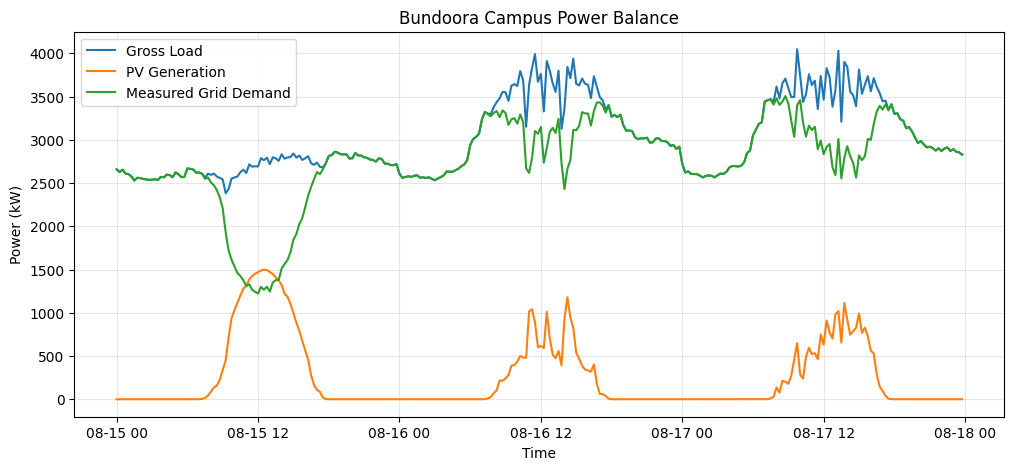

In [ ]:
# Extract a one-day diagnostic window for visual inspection of the baseline demand profile.
sample = check[
    (check['Timestamp'] >= '2021-08-15')
    & (check['Timestamp'] < '2021-08-18')
].copy()

plt.figure(figsize=(12, 5))

plt.plot(
    sample['Timestamp'],
    sample['Gross_Load_kW'],
    label='Gross Load'
)

plt.plot(
    sample['Timestamp'],
    sample['PV_kW'],
    label='PV Generation'
)

plt.plot(
    sample['Timestamp'],
    sample['Grid_Demand_kW'],
    label='Measured Grid Demand'
)

plt.xlabel('Time')
plt.ylabel('Power (kW)')
plt.title('Bundoora Campus Power Balance')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Battery operating parameters

A lithium-ion BESS is considered in this study. The battery operating characteristics were based on the lithium-ion system modeled in [3], which employs a 20–80% SOC operating range and a round-trip efficiency of 95%. The reported round-trip efficiency was represented using equal charge and discharge efficiencies, such that $\eta_c = \eta_d = \sqrt{0.95} = 0.9747$. This symmetric decomposition is a modeling assumption.

The BESS power and energy ratings were determined independently from the measured Bundoora campus demand profile rather than adopted from [3]. Peak-demand analysis resulted in a maximum discharge requirement of approximately 1.055 MW above the selected 95th-percentile threshold, while the 95th-percentile peak-event energy requirement was approximately 947 kWh. Considering the 20–80% SOC operating range and battery efficiency, a 1 MW/2 MWh reference BESS was selected. 50% initial SOC is selected as a reference


In [ ]:
# Reference BESS parameters

BATTERY_CAPACITY_KWH = 2000.0

MAX_CHARGE_KW = 1000.0
MAX_DISCHARGE_KW = 1000.0

SOC_MIN = 0.20
SOC_MAX = 0.80
SOC_INITIAL = 0.50

ROUND_TRIP_EFFICIENCY = 0.95

# Symmetric decomposition of round-trip efficiency
ETA_CHARGE = np.sqrt(ROUND_TRIP_EFFICIENCY)
ETA_DISCHARGE = np.sqrt(ROUND_TRIP_EFFICIENCY)

DT = 0.25  # 15 minutes

E_MIN = SOC_MIN * BATTERY_CAPACITY_KWH
E_MAX = SOC_MAX * BATTERY_CAPACITY_KWH
E_INITIAL = SOC_INITIAL * BATTERY_CAPACITY_KWH

print(f'Battery capacity: {BATTERY_CAPACITY_KWH:.0f} kWh')
print(f'Power rating: ±{MAX_CHARGE_KW:.0f} kW')
print(f'Energy limits: {E_MIN:.0f}–{E_MAX:.0f} kWh')
print(f'Initial energy: {E_INITIAL:.0f} kWh')
print(f'Charge efficiency: {ETA_CHARGE:.4f}')
print(f'Discharge efficiency: {ETA_DISCHARGE:.4f}')

Battery capacity: 2000 kWh
Power rating: ±1000 kW
Energy limits: 400–1600 kWh
Initial energy: 1000 kWh
Charge efficiency: 0.9747
Discharge efficiency: 0.9747


## 9. System power balance and battery model

With battery charging and discharging included, grid demand is modeled as:
$$
P_{\text{grid}}(t)
=
P_{\text{gross}}(t) - P_{\text{PV}}(t)
+ P_c(t) - P_d(t).
$$

For each 15-minute interval, stored energy evolves as

$$E_{k+1}=E_k+\eta_c P_{c,k}\Delta t-\frac{P_{d,k}}{\eta_d}\Delta t,$$

where $E_k$ is stored energy in kWh, $P_{c,k}$ and $P_{d,k}$ are charging and discharging power in kW, $\eta_c$ and $\eta_d$ are one-way efficiencies, and $\Delta t=0.25$ h.

`battery_step()` enforces power and energy limits before updating the physical battery state. The short tests below verify lower- and upper-SOC behavior.


In [ ]:
def battery_step(
    energy_kwh,
    charge_request_kw=0.0,
    discharge_request_kw=0.0
):
    '''
    Simulate one 15-minute battery step.

    Parameters
    ----------
    energy_kwh : float
        Battery energy at the beginning of the interval.

    charge_request_kw : float
        Requested charging power.

    discharge_request_kw : float
        Requested discharging power.

    Returns
    -------
    next_energy_kwh
    charge_kw
    discharge_kw
    '''

    # Requested powers cannot be negative
    charge_request_kw = max(charge_request_kw, 0.0)
    discharge_request_kw = max(discharge_request_kw, 0.0)

    # Apply inverter/power limits
    charge_kw = min(
        charge_request_kw,
        MAX_CHARGE_KW
    )

    discharge_kw = min(
        discharge_request_kw,
        MAX_DISCHARGE_KW
    )

    # Maximum charging power allowed by remaining
    # battery energy capacity
    max_charge_from_soc = (
        (E_MAX - energy_kwh)
        / (ETA_CHARGE * DT)
    )

    charge_kw = min(
        charge_kw,
        max_charge_from_soc
    )

    # Maximum discharge power allowed by available
    # battery energy
    max_discharge_from_soc = (
        (energy_kwh - E_MIN)
        * ETA_DISCHARGE
        / DT
    )

    discharge_kw = min(
        discharge_kw,
        max_discharge_from_soc
    )

    # Battery state equation
    next_energy_kwh = (
        energy_kwh
        + ETA_CHARGE * charge_kw * DT
        - (discharge_kw / ETA_DISCHARGE) * DT
    )

    return next_energy_kwh, charge_kw, discharge_kw

The battery constraint tests begin from the specified initial state of charge (SOC), providing the starting condition for all subsequent battery simulations.

In [ ]:
# Start the battery constraint tests from the configured initial state of charge.
energy = E_INITIAL

next_energy, charge, discharge = battery_step(
    energy_kwh=energy,
    discharge_request_kw=1000
)

print(f'Initial energy: {energy:.2f} kWh')
print(f'Actual discharge: {discharge:.2f} kW')
print(f'Next energy: {next_energy:.2f} kWh')
print(
    f'Next SOC: '
    f'{100 * next_energy / BATTERY_CAPACITY_KWH:.2f}%'
)

Initial energy: 1000.00 kWh
Actual discharge: 1000.00 kW
Next energy: 743.51 kWh
Next SOC: 37.18%


The second battery constraint test applies another 1 MW discharge request using the state of charge (SOC) remaining after the previous step. This demonstrates that the battery cannot sustain maximum discharge indefinitely, as the available energy decreases with continued operation. The results show how the achievable discharge power is progressively constrained as the SOC approaches its minimum limit.

In [ ]:
# Apply a second discharge request and record the constrained battery response.
energy_2, charge_2, discharge_2 = battery_step(
    energy_kwh=next_energy,
    discharge_request_kw=1000
)

print(f'Actual discharge: {discharge_2:.2f} kW')
print(f'Next energy: {energy_2:.2f} kWh')
print(
    f'Next SOC: '
    f'{100 * energy_2 / BATTERY_CAPACITY_KWH:.2f}%'
)

Actual discharge: 1000.00 kW
Next energy: 487.01 kWh
Next SOC: 24.35%


A third 1 MW discharge request is applied after the previous two discharges. At this point the battery is close to its minimum allowed energy.

The important result is that the requested 1 MW is no longer physically available for the full 15-minute interval. `battery_step()` reduces the actual discharge so that the next energy state reaches, but does not cross, the minimum energy limit.

This confirms that the controller cannot create energy simply because it requests a high discharge power.

In [ ]:
# Apply a third discharge request to verify that the minimum SOC constraint limits discharge power.
energy_3, charge_3, discharge_3 = battery_step(
    energy_kwh=energy_2,
    discharge_request_kw=1000
)

print(f'Initial energy: {energy_2:.2f} kWh')
print(f'Requested discharge: 1000.00 kW')
print(f'Actual discharge: {discharge_3:.2f} kW')
print(f'Next energy: {energy_3:.2f} kWh')
print(
    f'Next SOC: '
    f'{100 * energy_3 / BATTERY_CAPACITY_KWH:.2f}%'
)

Initial energy: 487.01 kWh
Requested discharge: 1000.00 kW
Actual discharge: 339.23 kW
Next energy: 400.00 kWh
Next SOC: 20.00%


### Verify the upper SOC limit during charging

The previous tests examined the lower energy boundary. Here the battery is initialized at 75% SOC and asked to charge at the full 1 MW rate.

Only enough power to reach the 80% maximum SOC is accepted. This confirms that the same physical model limits charging when the battery is nearly full and prevents the simulated energy state from exceeding its specified operating range.

In [ ]:
# Set the battery to a high SOC and test charging behavior near the upper energy limit.
energy = 1500.0  # 75% SOC

next_energy, charge, discharge = battery_step(
    energy_kwh=energy,
    charge_request_kw=1000
)

print(f'Initial energy: {energy:.2f} kWh')
print(f'Requested charge: 1000.00 kW')
print(f'Actual charge: {charge:.2f} kW')
print(f'Next energy: {next_energy:.2f} kWh')
print(
    f'Next SOC: '
    f'{100 * next_energy / BATTERY_CAPACITY_KWH:.2f}%'
)

Initial energy: 1500.00 kWh
Requested charge: 1000.00 kW
Actual charge: 410.39 kW
Next energy: 1600.00 kWh
Next SOC: 80.00%


## 10. Rule-based controller benchmark

The rule-based controller provides a simple comparison with MPC. The lower threshold is the 25th percentile of measured grid demand and the upper threshold is the 95th percentile. The controller requests charging below the lower threshold and discharging above the upper threshold; `battery_step()` enforces the actual BESS constraints.

Each continuous data block starts at 50% SOC. The rule is intentionally kept fixed rather than tuned after observing MPC results.


In [ ]:
# Extract the baseline grid-demand series used to define rule-controller thresholds.
grid = mpc_data['Grid_Demand_kW']

CHARGE_THRESHOLD = np.percentile(grid, 25)
DISCHARGE_THRESHOLD = np.percentile(grid, 95)

print(f'Charge threshold: {CHARGE_THRESHOLD:.1f} kW')
print(f'Discharge threshold: {DISCHARGE_THRESHOLD:.1f} kW')

Charge threshold: 2499.7 kW
Discharge threshold: 3517.4 kW


In [ ]:
def run_rule_based_controller(data):

    results = []
    energy = E_INITIAL

    for _, row in data.iterrows():

        grid_demand = row['Grid_Demand_kW']

        charge_request = 0.0
        discharge_request = 0.0
        requested_mode = 'Idle'

        # High demand -> request discharge for peak shaving
        if grid_demand > DISCHARGE_THRESHOLD:

            discharge_request = (
                grid_demand - DISCHARGE_THRESHOLD
            )

            requested_mode = 'Discharge'

        # Low demand -> request battery charging
        elif grid_demand < CHARGE_THRESHOLD:

            charge_request = (
                CHARGE_THRESHOLD - grid_demand
            )

            requested_mode = 'Charge'

        # Apply battery power and SOC constraints
        next_energy, charge_kw, discharge_kw = battery_step(
            energy_kwh=energy,
            charge_request_kw=charge_request,
            discharge_request_kw=discharge_request
        )

        # Determine actual operating mode after constraints
        if discharge_kw > 1e-9:
            actual_mode = 'Discharge'

        elif charge_kw > 1e-9:
            actual_mode = 'Charge'

        else:
            actual_mode = 'Idle'

        # Grid demand after battery action
        grid_with_battery = (
            grid_demand
            + charge_kw
            - discharge_kw
        )

        # SOC at end of interval
        soc = (
            next_energy
            / BATTERY_CAPACITY_KWH
        )

        results.append({
            'Timestamp': row['Timestamp'],
            'Grid_Baseline_kW': grid_demand,
            'Charge_kW': charge_kw,
            'Discharge_kW': discharge_kw,
            'Grid_RuleBased_kW': grid_with_battery,
            'Energy_kWh': next_energy,
            'SOC': soc,
            'Requested_Mode': requested_mode,
            'Actual_Mode': actual_mode
        })

        energy = next_energy

    return pd.DataFrame(results)

In [ ]:
# Copy the MPC input data so the rule-based controller can add its results without modifying the source.
rule_data = mpc_data.copy()

new_block = (
    rule_data['Timestamp'].diff()
    != pd.Timedelta(minutes=15)
)

rule_data['Block_ID'] = new_block.cumsum()

print('Number of continuous blocks:',
      rule_data['Block_ID'].nunique())

Number of continuous blocks: 195


In [ ]:
# Create a container for storing the rule-based controller output at each timestep.
rule_results = []

for block_id, block in rule_data.groupby('Block_ID'):

    block = block.copy()

    result = run_rule_based_controller(block)

    result['Block_ID'] = block_id

    rule_results.append(result)

rule_results = pd.concat(
    rule_results,
    ignore_index=True
)

In [ ]:
# Summarize the rule-based controller results after the full simulation.
display(
    rule_results[
        [
            'Charge_kW',
            'Discharge_kW',
            'Energy_kWh',
            'SOC'
        ]
    ].describe()
)

print(
    '\nMinimum SOC:',
    rule_results['SOC'].min()
)

print(
    'Maximum SOC:',
    rule_results['SOC'].max()
)

print(
    'Maximum charge power:',
    rule_results['Charge_kW'].max()
)

print(
    'Maximum discharge power:',
    rule_results['Discharge_kW'].max()
)

,Charge_kW,Discharge_kW,Energy_kWh,SOC
count,30875.000000,30875.000000,30875.000000,30875.000000
mean,7.942112,4.687038,1302.466840,0.651233
std,60.596662,34.698450,390.175644,0.195088
min,0.000000,0.000000,400.000000,0.200000
25%,0.000000,0.000000,1000.000000,0.500000
50%,0.000000,0.000000,1600.000000,0.800000
75%,0.000000,0.000000,1600.000000,0.800000
max,1000.000000,999.289667,1600.000000,0.800000



Minimum SOC: 0.2
Maximum SOC: 0.8
Maximum charge power: 1000.0
Maximum discharge power: 999.2896666666666


In [ ]:
# Compare the uncontrolled peak demand with the peak after rule-based battery control.
print(
    'Baseline peak demand:',
    rule_results['Grid_Baseline_kW'].max()
)

print(
    'Rule-based peak demand:',
    rule_results['Grid_RuleBased_kW'].max()
)

print(
    'Peak reduction:',
    rule_results['Grid_Baseline_kW'].max()
    - rule_results['Grid_RuleBased_kW'].max()
)

Baseline peak demand: 4572.367666666666
Rule-based peak demand: 4572.367666666666
Peak reduction: 0.0


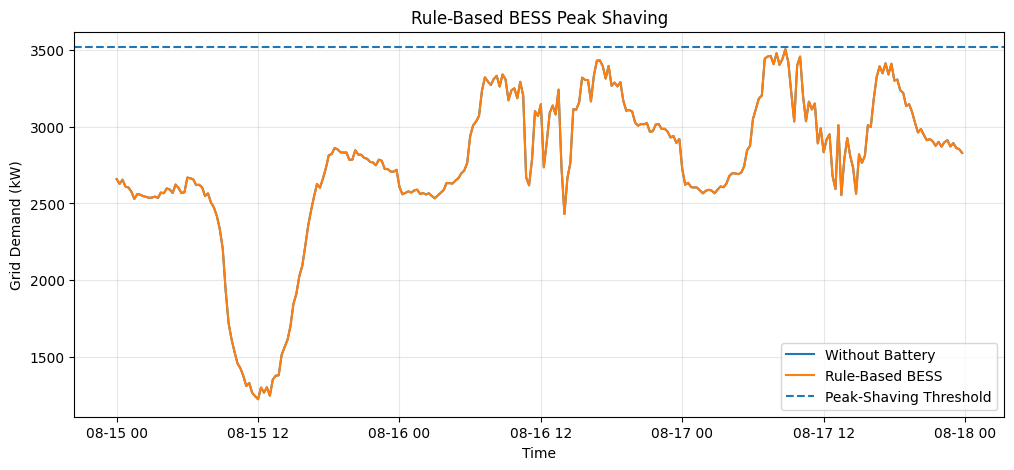

In [ ]:
# Extract a one-day rule-based diagnostic window for visual comparison with the baseline.
sample = rule_results[
    (rule_results['Timestamp'] >= '2021-08-15')
    & (rule_results['Timestamp'] < '2021-08-18')
]

plt.figure(figsize=(12, 5))

plt.plot(
    sample['Timestamp'],
    sample['Grid_Baseline_kW'],
    label='Without Battery'
)

plt.plot(
    sample['Timestamp'],
    sample['Grid_RuleBased_kW'],
    label='Rule-Based BESS'
)

plt.axhline(
    DISCHARGE_THRESHOLD,
    linestyle='--',
    label='Peak-Shaving Threshold'
)

plt.xlabel('Time')
plt.ylabel('Grid Demand (kW)')
plt.title('Rule-Based BESS Peak Shaving')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Why the rule-based controller misses the annual peak

The annual maximum is inspected directly. The controller requests discharge during several earlier threshold exceedances and eventually reaches the 20% minimum SOC. When the largest demand event arrives, discharge is still requested but the battery cannot respond.

This motivates a controller that allocates stored energy using information about future demand rather than reacting only to the current threshold crossing.


In [ ]:
# Locate the timestamp of the largest baseline grid-demand value.
peak_idx = rule_results['Grid_Baseline_kW'].idxmax()

rule_results.loc[
    peak_idx,
    [
        'Timestamp',
        'Grid_Baseline_kW',
        'Charge_kW',
        'Discharge_kW',
        'Grid_RuleBased_kW',
        'Energy_kWh',
        'SOC',
        'Requested_Mode',
        'Actual_Mode',
        'Block_ID'
    ]
]

,28100
Timestamp,2021-12-01 15:00:00
Grid_Baseline_kW,4572.367667
Charge_kW,0.0
Discharge_kW,0.0
Grid_RuleBased_kW,4572.367667
Energy_kWh,400.0
SOC,0.2
Requested_Mode,Discharge
Actual_Mode,Idle
Block_ID,179


A short window around the annual peak shows whether the battery was available when the largest demand occurred. This helps distinguish controller logic from battery depletion.

In [ ]:
# Retrieve the timestamp corresponding to the baseline annual peak.
peak_time = rule_results.loc[peak_idx, 'Timestamp']

peak_window = rule_results[
    (rule_results['Timestamp'] >= peak_time - pd.Timedelta(hours=8))
    &
    (rule_results['Timestamp'] <= peak_time + pd.Timedelta(hours=2))
]

peak_window[
    [
        'Timestamp',
        'Grid_Baseline_kW',
        'Charge_kW',
        'Discharge_kW',
        'Grid_RuleBased_kW',
        'Energy_kWh',
        'SOC',
        'Requested_Mode',
        'Actual_Mode'
    ]
]

,Timestamp,Grid_Baseline_kW,Charge_kW,Discharge_kW,Grid_RuleBased_kW,Energy_kWh,SOC,Requested_Mode,Actual_Mode
28068,2021-12-01 07:00:00,3019.350667,0.0,0.000000,3019.350667,1006.714404,0.503357,Idle,Idle
28069,2021-12-01 07:15:00,3005.935333,0.0,0.000000,3005.935333,1006.714404,0.503357,Idle,Idle
28070,2021-12-01 07:30:00,3153.548667,0.0,0.000000,3153.548667,1006.714404,0.503357,Idle,Idle
28071,2021-12-01 07:45:00,3324.431000,0.0,0.000000,3324.431000,1006.714404,0.503357,Idle,Idle
28072,2021-12-01 08:00:00,3394.761000,0.0,0.000000,3394.761000,1006.714404,0.503357,Idle,Idle
28073,2021-12-01 08:15:00,3110.824000,0.0,0.000000,3110.824000,1006.714404,0.503357,Idle,Idle
28074,2021-12-01 08:30:00,2850.229333,0.0,0.000000,2850.229333,1006.714404,0.503357,Idle,Idle
28075,2021-12-01 08:45:00,2805.971667,0.0,0.000000,2805.971667,1006.714404,0.503357,Idle,Idle
28076,2021-12-01 09:00:00,2761.881000,0.0,0.000000,2761.881000,1006.714404,0.503357,Idle,Idle
28077,2021-12-01 09:15:00,3107.728667,0.0,0.000000,3107.728667,1006.714404,0.503357,Idle,Idle


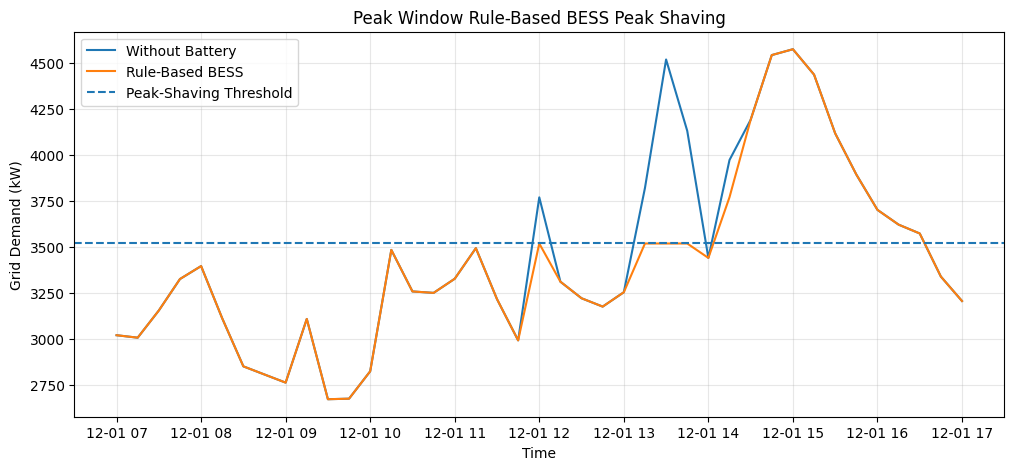

In [ ]:
# Peak window visualization
sample = peak_window

plt.figure(figsize=(12, 5))

plt.plot(
    sample['Timestamp'],
    sample['Grid_Baseline_kW'],
    label='Without Battery'
)

plt.plot(
    sample['Timestamp'],
    sample['Grid_RuleBased_kW'],
    label='Rule-Based BESS'
)

plt.axhline(
    DISCHARGE_THRESHOLD,
    linestyle='--',
    label='Peak-Shaving Threshold'
)

plt.xlabel('Time')
plt.ylabel('Grid Demand (kW)')
plt.title('Peak Window Rule-Based BESS Peak Shaving')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Compare baseline and rule-based grid demand to quantify peak shaving.
baseline = rule_results['Grid_Baseline_kW']
controlled = rule_results['Grid_RuleBased_kW']

print(
    f'Baseline peak: {baseline.max():.2f} kW'
)

print(
    f'Controlled peak: {controlled.max():.2f} kW'
)

for p in [90, 95, 97.5, 99]:
    base_p = np.percentile(baseline, p)
    ctrl_p = np.percentile(controlled, p)

    print(
        f'\n{p}th percentile:'
        f'\n  Baseline: {base_p:.2f} kW'
        f'\n  Controlled: {ctrl_p:.2f} kW'
        f'\n  Reduction: {base_p - ctrl_p:.2f} kW'
    )

discharged_energy = (
    rule_results['Discharge_kW'].sum() * DT
)

charged_energy = (
    rule_results['Charge_kW'].sum() * DT
)

print(
    f'\nTotal charging energy: '
    f'{charged_energy:.2f} kWh'
)

print(
    f'Total discharged energy: '
    f'{discharged_energy:.2f} kWh'
)

Baseline peak: 4572.37 kW
Controlled peak: 4572.37 kW

90th percentile:
  Baseline: 3318.61 kW
  Controlled: 3318.61 kW
  Reduction: 0.00 kW

95th percentile:
  Baseline: 3517.39 kW
  Controlled: 3517.29 kW
  Reduction: 0.09 kW

97.5th percentile:
  Baseline: 3659.01 kW
  Controlled: 3517.39 kW
  Reduction: 141.63 kW

99th percentile:
  Baseline: 3801.96 kW
  Controlled: 3698.11 kW
  Reduction: 103.84 kW

Total charging energy: 61303.17 kWh
Total discharged energy: 36178.08 kWh


## 11. Model Predictive Control formulation

At every 15-minute timestep, MPC optimizes battery charging and discharging over a finite prediction horizon, implements only the first action, then solves again at the next timestep.

The primary objective is to minimize the maximum predicted grid demand over the horizon, with a small battery-throughput penalty to discourage unnecessary cycling:

$$
\min
\left[
P_{\text{peak}}
+
\lambda \sum_{k=0}^{N-1}
(P_{c,k} + P_{d,k})\Delta t
\right].
$$

Subject to:

$$
P_{\text{grid},k}
=
\hat{P}_{\text{gross},k}
-
\hat{P}_{\text{PV},k}
+
P_{c,k}
-
P_{d,k},
$$

$$
P_{\text{grid},k} \leq P_{\text{peak}},
$$

$$
0 \leq P_{c,k} \leq P_{c,\max},
\qquad
0 \leq P_{d,k} \leq P_{d,\max},
$$

$$
E_{\min} \leq E_k \leq E_{\max},
$$

together with the battery energy-balance equation. Grid export is excluded in this initial peak-shaving formulation by imposing $P_{\text{grid},k} \geq 0$.

A small positive throughput penalty and efficiency losses make simultaneous charging and discharging unattractive; the resulting schedules are checked explicitly for simultaneous operation.

### Initial MPC horizon

The initial MPC uses 24 future 15-minute intervals, corresponding to a **6-hour prediction horizon**. This choice is subsequently tested against 2-, 4-, 8-, and 12-hour alternatives in the horizon-sensitivity experiment.


In [ ]:
HORIZON = 24  # 6 hours

def solve_mpc_window(
    load_forecast,
    pv_forecast,
    initial_energy,
    throughput_weight=0.001
):
    '''
    Solve one MPC optimization window.

    Parameters
    ----------
    load_forecast : array-like
        Forecast gross campus load (kW).

    pv_forecast : array-like
        Forecast PV generation (kW).

    initial_energy : float
        Battery energy at beginning of horizon (kWh).

    throughput_weight : float
        Small penalty on battery throughput.

    Returns
    -------
    Dictionary containing optimal battery schedule.
    '''

    load_forecast = np.asarray(load_forecast)
    pv_forecast = np.asarray(pv_forecast)

    N = len(load_forecast)

    # Decision variables
    charge = cp.Variable(N, nonneg=True)
    discharge = cp.Variable(N, nonneg=True)

    # N+1 states because E[0] is initial state
    energy = cp.Variable(N + 1)

    peak = cp.Variable()

    # Grid demand after battery operation
    grid_power = (
        load_forecast
        - pv_forecast
        + charge
        - discharge
    )

    constraints = [
        energy[0] == initial_energy,

        charge <= MAX_CHARGE_KW,
        discharge <= MAX_DISCHARGE_KW,

        energy >= E_MIN,
        energy <= E_MAX,

        grid_power <= peak,

        # No grid export
        grid_power >= 0
    ]

    # Battery dynamics
    for k in range(N):

        constraints.append(
            energy[k + 1]
            ==
            energy[k]
            + ETA_CHARGE * charge[k] * DT
            - discharge[k] * DT / ETA_DISCHARGE
        )

    # Battery throughput in kWh
    throughput = cp.sum(
        (charge + discharge) * DT
    )

    objective = cp.Minimize(
        peak
        + throughput_weight * throughput
    )

    problem = cp.Problem(
        objective,
        constraints
    )

    problem.solve(
        solver=cp.CLARABEL
    )

    if problem.status not in [
        cp.OPTIMAL,
        cp.OPTIMAL_INACCURATE
    ]:
        raise RuntimeError(
            f'MPC optimization failed: {problem.status}'
        )

    return {
        'charge': charge.value,
        'discharge': discharge.value,
        'energy': energy.value,
        'grid_power': grid_power.value,
        'peak': peak.value,
        'objective': problem.value,
        'status': problem.status
    }

### Single-window optimization check

A six-hour window on 1 December is first solved as one finite-horizon optimization. This diagnostic verifies the schedule, SOC limits, power limits, and absence of meaningful simultaneous charging/discharging before the controller is run in receding-horizon form.


In [ ]:
# Select the fixed six-hour period used to inspect the MPC optimization schedule.
test_window = mpc_data[
    (mpc_data['Timestamp'] >= '2021-12-01 12:00:00')
    &
    (mpc_data['Timestamp'] < '2021-12-01 18:00:00')
].copy()

print('Intervals:', len(test_window))

mpc_test = solve_mpc_window(
    load_forecast=test_window['Gross_Load_kW'].values,
    pv_forecast=test_window['PV_kW'].values,
    initial_energy=1006.714404
)

print(f'Status: {mpc_test['status']}')
print(
    f'Baseline peak: '
    f'{test_window['Grid_Demand_kW'].max():.2f} kW'
)
print(
    f'Optimized peak: '
    f'{mpc_test['peak']:.2f} kW'
)

Intervals: 24
Status: optimal
Baseline peak: 4572.37 kW
Optimized peak: 3756.11 kW


In [ ]:
# Organize the optimized charge, discharge, SOC, and grid-power trajectories for inspection.
mpc_schedule = pd.DataFrame({
    'Timestamp': test_window['Timestamp'].values,
    'Baseline_Grid_kW':
        test_window['Grid_Demand_kW'].values,
    'Charge_kW':
        mpc_test['charge'],
    'Discharge_kW':
        mpc_test['discharge'],
    'MPC_Grid_kW':
        mpc_test['grid_power'],
    'SOC_Start':
        mpc_test['energy'][:-1]
        / BATTERY_CAPACITY_KWH,
    'SOC_End':
        mpc_test['energy'][1:]
        / BATTERY_CAPACITY_KWH
})

mpc_schedule

,Timestamp,Baseline_Grid_kW,Charge_kW,Discharge_kW,MPC_Grid_kW,SOC_Start,SOC_End
0,2021-12-01 12:00:00,3768.070333,0.000002,11.962739,3756.107596,0.503357,0.501823
1,2021-12-01 12:15:00,3309.887000,446.220598,0.000002,3756.107596,0.501823,0.556188
2,2021-12-01 12:30:00,3220.013000,536.094598,0.000002,3756.107596,0.556188,0.621503
3,2021-12-01 12:45:00,3174.724667,581.382931,0.000002,3756.107596,0.621503,0.692336
4,2021-12-01 13:00:00,3252.720667,503.386931,0.000002,3756.107596,0.692336,0.753666
5,2021-12-01 13:15:00,3818.929333,0.000001,62.821738,3756.107596,0.753666,0.745609
6,2021-12-01 13:30:00,4516.677000,0.000002,760.569405,3756.107596,0.745609,0.648068
7,2021-12-01 13:45:00,4129.212333,0.000002,373.104739,3756.107596,0.648068,0.600219
8,2021-12-01 14:00:00,3439.104333,317.003265,0.000002,3756.107596,0.600219,0.638841
9,2021-12-01 14:15:00,3970.723000,0.000002,214.615405,3756.107596,0.638841,0.611317


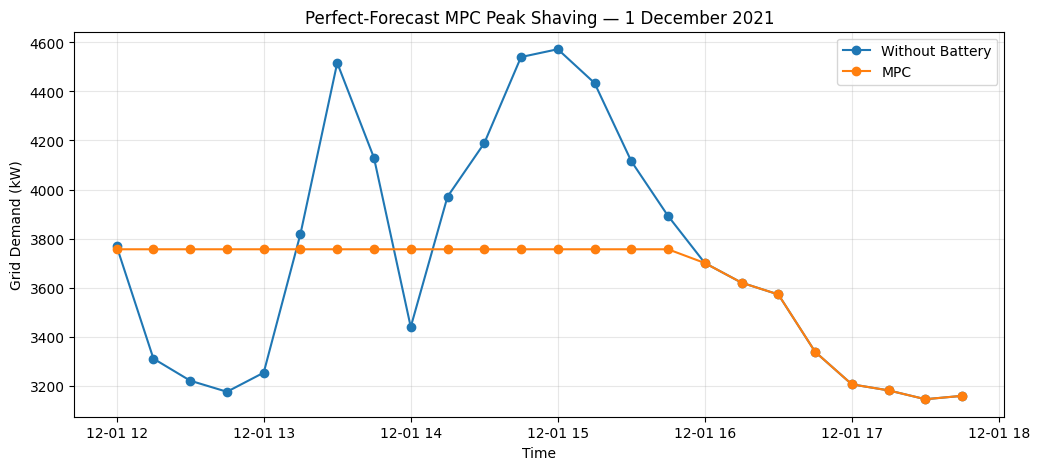

In [ ]:
# Plot the single-window MPC schedule against the baseline grid-demand profile.
plt.figure(figsize=(12, 5))

plt.plot(
    mpc_schedule['Timestamp'],
    mpc_schedule['Baseline_Grid_kW'],
    marker='o',
    label='Without Battery'
)

plt.plot(
    mpc_schedule['Timestamp'],
    mpc_schedule['MPC_Grid_kW'],
    marker='o',
    label='MPC'
)

plt.xlabel('Time')
plt.ylabel('Grid Demand (kW)')
plt.title(
    'Perfect-Forecast MPC Peak Shaving — '
    '1 December 2021'
)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Define a numerical tolerance for distinguishing true simultaneous charging/discharging from solver noise.
tolerance = 1e-3

simultaneous = mpc_schedule[
    (mpc_schedule['Charge_kW'] > tolerance)
    &
    (mpc_schedule['Discharge_kW'] > tolerance)
]

print(
    'Intervals with simultaneous charging/discharging:',
    len(simultaneous)
)

Intervals with simultaneous charging/discharging: 0


In [ ]:
# Report the battery-state and power-limit checks for the optimized single-window schedule.
print(
    f'Minimum SOC: '
    f'{mpc_schedule['SOC_End'].min():.4f}'
)

print(
    f'Maximum SOC: '
    f'{mpc_schedule['SOC_End'].max():.4f}'
)

print(
    f'Maximum charge power: '
    f'{mpc_schedule['Charge_kW'].max():.2f} kW'
)

print(
    f'Maximum discharge power: '
    f'{mpc_schedule['Discharge_kW'].max():.2f} kW'
)

print(
    f'Charging energy: '
    f'{mpc_schedule['Charge_kW'].sum() * DT:.2f} kWh'
)

print(
    f'Discharged energy: '
    f'{mpc_schedule['Discharge_kW'].sum() * DT:.2f} kWh'
)

print(
    'Intervals with simultaneous charging/discharging:',
    len(simultaneous)
)

Minimum SOC: 0.2000
Maximum SOC: 0.7537
Maximum charge power: 581.38 kW
Maximum discharge power: 816.26 kW
Charging energy: 596.02 kWh
Discharged energy: 1157.57 kWh
Intervals with simultaneous charging/discharging: 0


## 12. Receding-horizon MPC

A single call to `solve_mpc_window()` plans an entire future schedule. Receding-horizon MPC repeatedly solves that problem, implements **only the first** charging/discharging action, updates the physical battery state, shifts forward by one 15-minute interval, and solves again. The perfect-forecast benchmark supplies measured future load and PV as if they were known; forecast uncertainty is introduced later.


In [ ]:
def run_mpc_controller(
    data,
    horizon=24,
    throughput_weight=0.001
):
    '''
    Run receding-horizon MPC over one continuous data block.

    Perfect forecasts are assumed: actual future gross load and PV
    are supplied to the optimizer over each prediction horizon.
    '''

    data = data.copy().reset_index(drop=True)

    results = []

    energy = E_INITIAL

    for t in range(len(data)):

        # Remaining observations in this continuous block
        remaining = len(data) - t

        # Shorten horizon near the end of the block
        N = min(horizon, remaining)

        forecast_window = data.iloc[t:t + N]

        # Solve current MPC problem
        solution = solve_mpc_window(
            load_forecast=
                forecast_window['Gross_Load_kW'].values,

            pv_forecast=
                forecast_window['PV_kW'].values,

            initial_energy=energy,

            throughput_weight=throughput_weight
        )

        # Implement ONLY the first optimal action
        charge_kw = max(
            float(solution['charge'][0]),
            0.0
        )

        discharge_kw = max(
            float(solution['discharge'][0]),
            0.0
        )

        # Remove solver numerical noise
        if charge_kw < 1e-3:
            charge_kw = 0.0

        if discharge_kw < 1e-3:
            discharge_kw = 0.0

        # Use battery model to apply the action
        next_energy, charge_kw, discharge_kw = battery_step(
            energy_kwh=energy,
            charge_request_kw=charge_kw,
            discharge_request_kw=discharge_kw
        )

        baseline_grid = data.loc[
            t,
            'Grid_Demand_kW'
        ]

        grid_mpc = (
            baseline_grid
            + charge_kw
            - discharge_kw
        )

        results.append({
            'Timestamp':
                data.loc[t, 'Timestamp'],

            'Grid_Baseline_kW':
                baseline_grid,

            'Charge_kW':
                charge_kw,

            'Discharge_kW':
                discharge_kw,

            'Grid_MPC_kW':
                grid_mpc,

            'Energy_kWh':
                next_energy,

            'SOC':
                next_energy
                / BATTERY_CAPACITY_KWH,

            'Forecast_Horizon':
                N,

            'Predicted_Peak_kW':
                float(solution['peak'])
        })

        # Advance battery state
        energy = next_energy

    return pd.DataFrame(results)

In [ ]:
# Extract the December 1 test period used to inspect the receding-horizon controller.
dec1_test = mpc_data[
    (mpc_data['Timestamp'] >= '2021-12-01 12:00:00')
    &
    (mpc_data['Timestamp'] < '2021-12-01 18:00:00')
].copy()

dec1_mpc = run_mpc_controller(
    dec1_test,
    horizon=24
)

print(
    f'Baseline peak: '
    f'{dec1_mpc['Grid_Baseline_kW'].max():.2f} kW'
)

print(
    f'MPC peak: '
    f'{dec1_mpc['Grid_MPC_kW'].max():.2f} kW'
)

print(
    f'Peak reduction: '
    f'{dec1_mpc['Grid_Baseline_kW'].max() - dec1_mpc['Grid_MPC_kW'].max():.2f} kW'
)

print(
    f'Minimum SOC: '
    f'{dec1_mpc['SOC'].min():.4f}'
)

print(
    f'Maximum SOC: '
    f'{dec1_mpc['SOC'].max():.4f}'
)

print(
    f'Maximum charge power: '
    f'{dec1_mpc['Charge_kW'].max():.2f} kW'
)

print(
    f'Maximum discharge power: '
    f'{dec1_mpc['Discharge_kW'].max():.2f} kW'
)

Baseline peak: 4572.37 kW
MPC peak: 3757.77 kW
Peak reduction: 814.60 kW
Minimum SOC: 0.2000
Maximum SOC: 0.7513
Maximum charge power: 583.05 kW
Maximum discharge power: 814.60 kW


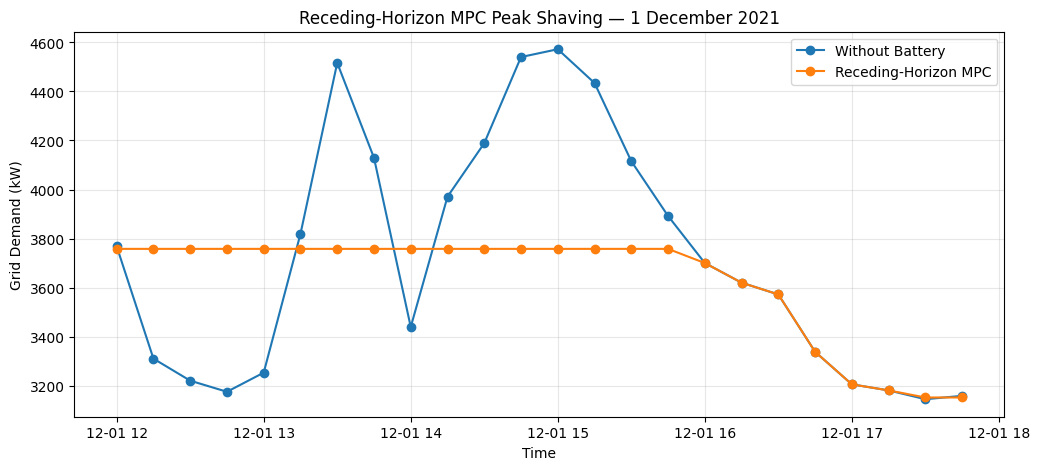

In [ ]:
# Plot the receding-horizon MPC grid-demand response for the selected one-day diagnostic period.
plt.figure(figsize=(12, 5))

plt.plot(
    dec1_mpc['Timestamp'],
    dec1_mpc['Grid_Baseline_kW'],
    marker='o',
    label='Without Battery'
)

plt.plot(
    dec1_mpc['Timestamp'],
    dec1_mpc['Grid_MPC_kW'],
    marker='o',
    label='Receding-Horizon MPC'
)

plt.xlabel('Time')
plt.ylabel('Grid Demand (kW)')
plt.title(
    'Receding-Horizon MPC Peak Shaving — '
    '1 December 2021'
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 13. Full-dataset perfect-forecast evaluation

MPC is evaluated independently on every continuous block containing at least one full prediction horizon. This avoids optimizing across unresolved data gaps. The comparison uses the same evaluated timestamps for no-BESS, rule-based, and MPC strategies.


In [ ]:
MIN_BLOCK_LENGTH = HORIZON

mpc_results = []

block_summary = []

for block_id, block in rule_data.groupby('Block_ID'):

    block = block.copy().reset_index(drop=True)

    if len(block) < MIN_BLOCK_LENGTH:
        continue

    result = run_mpc_controller(
        block,
        horizon=HORIZON,
        throughput_weight=0.001
    )

    result['Block_ID'] = block_id

    mpc_results.append(result)

    block_summary.append({
        'Block_ID': block_id,
        'Start': block['Timestamp'].iloc[0],
        'End': block['Timestamp'].iloc[-1],
        'Observations': len(block),
        'Baseline_Peak_kW':
            result['Grid_Baseline_kW'].max(),
        'MPC_Peak_kW':
            result['Grid_MPC_kW'].max()
    })

mpc_results = pd.concat(
    mpc_results,
    ignore_index=True
)

mpc_block_summary = pd.DataFrame(block_summary)

print(
    f'Evaluated observations: {len(mpc_results):,}'
)

print(
    f'Evaluated blocks: {len(mpc_block_summary):,}'
)

print(
    f'Coverage of cleaned dataset: '
    f'{100 * len(mpc_results) / len(mpc_data):.2f}%'
)

Evaluated observations: 30,618
Evaluated blocks: 162
Coverage of cleaned dataset: 99.17%


In [ ]:
# Calculate demand percentiles used for evaluation or control.
baseline = mpc_results['Grid_Baseline_kW']
controlled = mpc_results['Grid_MPC_kW']

baseline_peak = baseline.max()
mpc_peak = controlled.max()

print(f'Baseline peak: {baseline_peak:.2f} kW')
print(f'MPC peak: {mpc_peak:.2f} kW')
print(
    f'Peak reduction: '
    f'{baseline_peak - mpc_peak:.2f} kW'
)
print(
    f'Peak reduction (%): '
    f'{100 * (baseline_peak - mpc_peak) / baseline_peak:.2f}%'
)

for p in [90, 95, 97.5, 99]:

    base_p = np.percentile(baseline, p)
    mpc_p = np.percentile(controlled, p)

    print(
        f'\n{p}th percentile:'
        f'\n  Baseline: {base_p:.2f} kW'
        f'\n  MPC: {mpc_p:.2f} kW'
        f'\n  Reduction: {base_p - mpc_p:.2f} kW'
    )

print(
    f'\nMinimum SOC: '
    f'{mpc_results['SOC'].min():.4f}'
)

print(
    f'Maximum SOC: '
    f'{mpc_results['SOC'].max():.4f}'
)

print(
    f'Maximum charge power: '
    f'{mpc_results['Charge_kW'].max():.2f} kW'
)

print(
    f'Maximum discharge power: '
    f'{mpc_results['Discharge_kW'].max():.2f} kW'
)


Baseline peak: 4572.37 kW
MPC peak: 3773.23 kW
Peak reduction: 799.14 kW
Peak reduction (%): 17.48%

90th percentile:
  Baseline: 3307.20 kW
  MPC: 3190.57 kW
  Reduction: 116.63 kW

95th percentile:
  Baseline: 3501.25 kW
  MPC: 3332.61 kW
  Reduction: 168.64 kW

97.5th percentile:
  Baseline: 3638.98 kW
  MPC: 3445.40 kW
  Reduction: 193.57 kW

99th percentile:
  Baseline: 3779.94 kW
  MPC: 3569.68 kW
  Reduction: 210.26 kW

Minimum SOC: 0.2000
Maximum SOC: 0.8000
Maximum charge power: 1000.00 kW
Maximum discharge power: 894.48 kW


### No-BESS vs rule-based vs MPC
The comparison uses identical timestamps for all strategies. In addition to the annual maximum, upper-demand percentiles and performance specifically above the baseline P95 threshold are examined.

In [ ]:
# Keep rule-based results only for timestamps evaluated by MPC
rule_comparison = rule_results[
    rule_results['Timestamp'].isin(
        mpc_results['Timestamp']
    )
].copy()

# Merge rule-based and MPC results
comparison = pd.merge(
    mpc_results[
        [
            'Timestamp',
            'Grid_Baseline_kW',
            'Grid_MPC_kW'
        ]
    ],
    rule_comparison[
        [
            'Timestamp',
            'Grid_RuleBased_kW'
        ]
    ],
    on='Timestamp',
    how='inner'
)

print('Comparison observations:', len(comparison))

Comparison observations: 30618


In [ ]:
# Build a common strategy table containing the no-BESS, rule-based, and MPC grid-demand trajectories.
strategies = {
    'No BESS': comparison['Grid_Baseline_kW'],
    'Rule-Based': comparison['Grid_RuleBased_kW'],
    'MPC': comparison['Grid_MPC_kW']
}

summary = []

for name, values in strategies.items():

    summary.append({
        'Strategy': name,
        'Peak_kW': values.max(),
        'P90_kW': np.percentile(values, 90),
        'P95_kW': np.percentile(values, 95),
        'P97.5_kW': np.percentile(values, 97.5),
        'P99_kW': np.percentile(values, 99)
    })

comparison_summary = pd.DataFrame(summary)

comparison_summary

,Strategy,Peak_kW,P90_kW,P95_kW,P97.5_kW,P99_kW
0,No BESS,4572.367667,3307.197700,3501.250400,3638.975100,3779.935320
1,Rule-Based,4572.367667,3307.197700,3501.250400,3517.387333,3684.686240
2,MPC,3773.232591,3190.569434,3332.605459,3445.400343,3569.675174


### Isolate the observations where peak shaving is most relevant
The 95th-percentile demand threshold is used to define high-demand intervals. Observations where baseline demand exceeds this threshold are retained, and controller performance is compared within this subset.

The purpose is complementary to the annual peak metric: it asks how the controllers behave across the broader group of unusually high-demand periods rather than focusing on a single maximum.

In [ ]:
# Extract the no-BESS peak so reductions for controlled strategies can be reported consistently.
baseline_peak = comparison_summary.loc[
    comparison_summary['Strategy'] == 'No BESS',
    'Peak_kW'
].iloc[0]

comparison_summary['Peak_Reduction_kW'] = (
    baseline_peak
    - comparison_summary['Peak_kW']
)

comparison_summary['Peak_Reduction_pct'] = (
    100
    * comparison_summary['Peak_Reduction_kW']
    / baseline_peak
)

comparison_summary

,Strategy,Peak_kW,P90_kW,P95_kW,P97.5_kW,P99_kW,Peak_Reduction_kW,Peak_Reduction_pct
0,No BESS,4572.367667,3307.197700,3501.250400,3638.975100,3779.935320,0.000000,0.000000
1,Rule-Based,4572.367667,3307.197700,3501.250400,3517.387333,3684.686240,0.000000,0.000000
2,MPC,3773.232591,3190.569434,3332.605459,3445.400343,3569.675174,799.135076,17.477489


In [ ]:
p95_threshold = np.percentile(
    comparison['Grid_Baseline_kW'],
    95
)

high_demand = comparison[
    comparison['Grid_Baseline_kW'] > p95_threshold
].copy()

high_demand['Rule_Reduction_kW'] = (
    high_demand['Grid_Baseline_kW']
    - high_demand['Grid_RuleBased_kW']
)

high_demand['MPC_Reduction_kW'] = (
    high_demand['Grid_Baseline_kW']
    - high_demand['Grid_MPC_kW']
)

print(f'P95 threshold: {p95_threshold:.2f} kW')

print(
    f'\nMean Rule-Based reduction above P95: '
    f'{high_demand['Rule_Reduction_kW'].mean():.2f} kW'
)

print(
    f'Mean MPC reduction above P95: '
    f'{high_demand['MPC_Reduction_kW'].mean():.2f} kW'
)

print(
    f'\nRule-Based intervals reduced: '
    f'{(high_demand['Rule_Reduction_kW'] > 1e-3).mean() * 100:.2f}%'
)

print(
    f'MPC intervals reduced: '
    f'{(high_demand['MPC_Reduction_kW'] > 1e-3).mean() * 100:.2f}%'
)

P95 threshold: 3501.25 kW

Mean Rule-Based reduction above P95: 74.77 kW
Mean MPC reduction above P95: 278.19 kW

Rule-Based intervals reduced: 56.04%
MPC intervals reduced: 95.43%


## 14. Prediction-horizon sensitivity

Prediction horizons of 2, 4, 6, 8, and 12 hours are compared on the longest continuous data block. Longer horizons provide more foresight but increase optimization time. The 6-hour (24-step) horizon is retained because the observed peak-reduction gains largely saturate beyond six hours while runtime continues to rise. This is a pragmatic study selection, not a proof of global optimality.


In [ ]:
# ---------------------------------------------------------
# Horizon sensitivity analysis
# ---------------------------------------------------------

# Find the longest continuous block
block_sizes = (
    rule_data
    .groupby('Block_ID')
    .size()
    .sort_values(ascending=False)
)

longest_block_id = block_sizes.index[0]

horizon_data = (
    rule_data[
        rule_data['Block_ID'] == longest_block_id
    ]
    .copy()
    .reset_index(drop=True)
)

print(f'Block ID: {longest_block_id}')
print(f'Observations: {len(horizon_data):,}')
print(
    f'Period: {horizon_data['Timestamp'].min()} '
    f'to {horizon_data['Timestamp'].max()}'
)

# Prediction horizons to evaluate
horizons = {
    '2 hours': 8,
    '4 hours': 16,
    '6 hours': 24,
    '8 hours': 32,
    '12 hours': 48
}

horizon_results = []

# Same baseline for every horizon
baseline = horizon_data['Grid_Demand_kW']
baseline_peak = baseline.max()
baseline_p95 = np.percentile(baseline, 95)
baseline_p99 = np.percentile(baseline, 99)

# Run MPC for each prediction horizon
for name, steps in horizons.items():

    print(f'\nRunning {name} horizon...')

    start_time = time.time()

    result = run_mpc_controller(
        horizon_data,
        horizon=steps,
        throughput_weight=0.001
    )

    runtime = time.time() - start_time

    mpc_grid = result['Grid_MPC_kW']

    mpc_peak = mpc_grid.max()
    mpc_p95 = np.percentile(mpc_grid, 95)
    mpc_p99 = np.percentile(mpc_grid, 99)

    horizon_results.append({
        'Horizon': name,
        'Steps': steps,

        'Baseline_Peak_kW':
            baseline_peak,

        'MPC_Peak_kW':
            mpc_peak,

        'Peak_Reduction_kW':
            baseline_peak - mpc_peak,

        'Peak_Reduction_pct':
            100 * (
                baseline_peak - mpc_peak
            ) / baseline_peak,

        'Baseline_P95_kW':
            baseline_p95,

        'MPC_P95_kW':
            mpc_p95,

        'P95_Reduction_kW':
            baseline_p95 - mpc_p95,

        'Baseline_P99_kW':
            baseline_p99,

        'MPC_P99_kW':
            mpc_p99,

        'P99_Reduction_kW':
            baseline_p99 - mpc_p99,

        'Min_SOC':
            result['SOC'].min(),

        'Max_SOC':
            result['SOC'].max(),

        'Max_Charge_kW':
            result['Charge_kW'].max(),

        'Max_Discharge_kW':
            result['Discharge_kW'].max(),

        'Runtime_seconds':
            runtime
    })

    print(
        f'Peak: {mpc_peak:.2f} kW | '
        f'Reduction: '
        f'{baseline_peak - mpc_peak:.2f} kW | '
        f'Runtime: {runtime:.1f} s'
    )

# Convert results to DataFrame
horizon_comparison = pd.DataFrame(
    horizon_results
)

# Display rounded results
horizon_comparison.round({
    'Baseline_Peak_kW': 2,
    'MPC_Peak_kW': 2,
    'Peak_Reduction_kW': 2,
    'Peak_Reduction_pct': 2,
    'Baseline_P95_kW': 2,
    'MPC_P95_kW': 2,
    'P95_Reduction_kW': 2,
    'Baseline_P99_kW': 2,
    'MPC_P99_kW': 2,
    'P99_Reduction_kW': 2,
    'Min_SOC': 4,
    'Max_SOC': 4,
    'Max_Charge_kW': 2,
    'Max_Discharge_kW': 2,
    'Runtime_seconds': 1
})


Block ID: 151
Observations: 3,396
Period: 2021-08-12 00:15:00 to 2021-09-16 09:00:00

Running 2 hours horizon...
Peak: 3450.78 kW | Reduction: 178.04 kW | Runtime: 103.2 s

Running 4 hours horizon...
Peak: 3340.34 kW | Reduction: 288.49 kW | Runtime: 164.2 s

Running 6 hours horizon...
Peak: 3294.40 kW | Reduction: 334.42 kW | Runtime: 223.7 s

Running 8 hours horizon...
Peak: 3292.97 kW | Reduction: 335.85 kW | Runtime: 286.5 s

Running 12 hours horizon...
Peak: 3292.97 kW | Reduction: 335.85 kW | Runtime: 409.8 s


,Horizon,Steps,Baseline_Peak_kW,MPC_Peak_kW,Peak_Reduction_kW,Peak_Reduction_pct,Baseline_P95_kW,MPC_P95_kW,P95_Reduction_kW,Baseline_P99_kW,MPC_P99_kW,P99_Reduction_kW,Min_SOC,Max_SOC,Max_Charge_kW,Max_Discharge_kW,Runtime_seconds
0,2 hours,8,3628.82,3450.78,178.04,4.91,3315.5,3194.05,121.44,3487.32,3365.76,121.56,0.2,0.6141,749.92,697.68,103.2
1,4 hours,16,3628.82,3340.34,288.49,7.95,3315.5,3127.79,187.71,3487.32,3257.44,229.88,0.2,0.8000,935.10,697.28,164.2
2,6 hours,24,3628.82,3294.40,334.42,9.22,3315.5,3097.92,217.57,3487.32,3195.15,292.17,0.2,0.8000,894.44,697.28,223.7
3,8 hours,32,3628.82,3292.97,335.85,9.26,3315.5,3086.07,229.43,3487.32,3195.15,292.17,0.2,0.8000,945.87,697.28,286.5
4,12 hours,48,3628.82,3292.97,335.85,9.26,3315.5,3083.05,232.44,3487.32,3195.15,292.17,0.2,0.8000,946.70,656.06,409.8


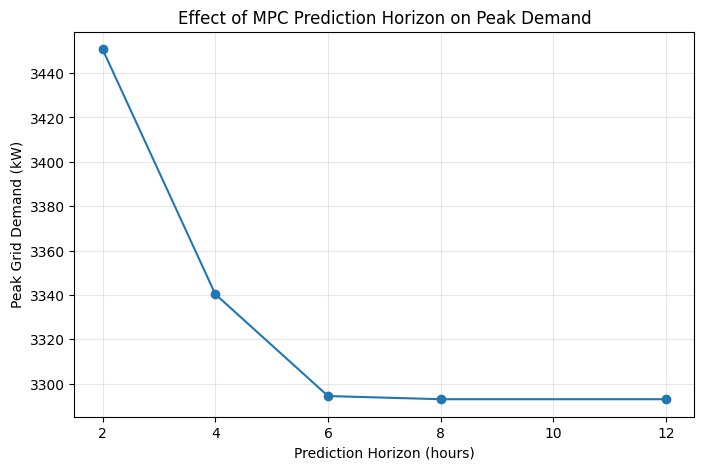

In [ ]:
# Plot peak demand against prediction horizon to show where additional look-ahead provides diminishing gains.
plt.figure(figsize=(8, 5))

plt.plot(
    horizon_comparison['Steps'] / 4,
    horizon_comparison['MPC_Peak_kW'],
    marker='o'
)

plt.xlabel('Prediction Horizon (hours)')
plt.ylabel('Peak Grid Demand (kW)')
plt.title('Effect of MPC Prediction Horizon on Peak Demand')
plt.grid(alpha=0.3)

plt.show()

## 15. Forecast uncertainty

The perfect-forecast benchmark is optimistic. Forecast sensitivity is therefore tested with synthetic temporally correlated multiplicative errors. For each series,

$$\epsilon_k=\rho\epsilon_{k-1}+\sqrt{1-\rho^2}\,z_k,$$

where $z_k$ is a zero-mean random innovation and $\rho=0.8$ is a scenario assumption. The `error_level` parameter controls the innovation standard deviation; it is **not MAPE**. Realized MAE, RMSE, and MAPE are calculated separately for each scenario, and negative load/PV forecasts are clipped to zero.



In [ ]:
def generate_forecast(
    actual_values,
    error_level,
    rng,
    correlation=0.8
):
    '''
    Generate a synthetic forecast with temporally correlated
    multiplicative errors.

    error_level controls the standard deviation of the
    relative forecast error.
    '''

    actual_values = np.asarray(
        actual_values,
        dtype=float
    )

    N = len(actual_values)

    errors = np.zeros(N)

    # Initial error
    errors[0] = rng.normal(
        loc=0.0,
        scale=error_level
    )

    # AR(1)-style correlated errors
    for k in range(1, N):

        innovation = rng.normal(
            loc=0.0,
            scale=error_level
        )

        errors[k] = (
            correlation * errors[k - 1]
            + np.sqrt(1 - correlation**2)
            * innovation
        )

    forecast = actual_values * (1 + errors)

    # Physical quantities cannot be negative
    forecast = np.maximum(
        forecast,
        0.0
    )

    return forecast

### Forecast trajectories used by MPC

One coherent load and PV forecast trajectory is generated for each simulation run. At every MPC timestep, the optimizer sees the appropriate next 24 values from that trajectory. The battery action is selected using the forecasts but evaluated against the measured grid demand, preserving the distinction between predicted and realized system operation.


In [ ]:
def create_forecast_trajectory(
    data,
    error_level,
    seed=42,
    correlation=0.8
):
    '''
    Generate temporally correlated synthetic load and PV
    forecast trajectories for an entire continuous block.

    error_level is the standard deviation of the
    multiplicative error process.
    '''

    rng = np.random.default_rng(seed)

    load_forecast = generate_forecast(
        data['Gross_Load_kW'].values,
        error_level=error_level,
        rng=rng,
        correlation=correlation
    )

    pv_forecast = generate_forecast(
        data['PV_kW'].values,
        error_level=error_level,
        rng=rng,
        correlation=correlation
    )

    forecast_data = data.copy()

    forecast_data[
        'Gross_Load_Forecast_kW'
    ] = load_forecast

    forecast_data[
        'PV_Forecast_kW'
    ] = pv_forecast

    return forecast_data

### MPC using imperfect forecasts

The MPC optimization receives the synthetic forecast instead of measured future values. The resulting battery action is evaluated against the actual measured system to quantify realized peak-demand performance.

In [ ]:
def run_mpc_with_forecasts(
    data,
    horizon=24,
    throughput_weight=0.001
):
    '''
    Receding-horizon MPC using pre-generated forecasts.

    Optimization decisions use forecast load/PV, while
    performance is evaluated using measured grid demand.
    '''

    data = data.copy().reset_index(drop=True)

    results = []

    energy = E_INITIAL

    # Use the forecast trajectory to make the MPC decision, but evaluate the action against actual measured data.
    for t in range(len(data)):

        remaining = len(data) - t
        N = min(horizon, remaining)

        window = data.iloc[t:t + N]

        load_forecast = (
            window['Gross_Load_Forecast_kW']
            .to_numpy()
        )

        pv_forecast = (
            window['PV_Forecast_kW']
            .to_numpy()
        )

        solution = solve_mpc_window(
            load_forecast=load_forecast,
            pv_forecast=pv_forecast,
            initial_energy=energy,
            throughput_weight=throughput_weight
        )

        charge_kw = max(
            float(solution['charge'][0]),
            0.0
        )

        discharge_kw = max(
            float(solution['discharge'][0]),
            0.0
        )

        if charge_kw < 1e-3:
            charge_kw = 0.0

        if discharge_kw < 1e-3:
            discharge_kw = 0.0

        next_energy, charge_kw, discharge_kw = (
            battery_step(
                energy_kwh=energy,
                charge_request_kw=charge_kw,
                discharge_request_kw=discharge_kw
            )
        )

        actual_grid = data.loc[
            t,
            'Grid_Demand_kW'
        ]

        grid_mpc = (
            actual_grid
            + charge_kw
            - discharge_kw
        )

        results.append({
            'Timestamp':
                data.loc[t, 'Timestamp'],

            'Grid_Baseline_kW':
                actual_grid,

            'Charge_kW':
                charge_kw,

            'Discharge_kW':
                discharge_kw,

            'Grid_MPC_kW':
                grid_mpc,

            'Energy_kWh':
                next_energy,

            'SOC':
                next_energy
                / BATTERY_CAPACITY_KWH
        })

        energy = next_energy

    return pd.DataFrame(results)


In [ ]:
def forecast_error_metrics(
    actual,
    forecast
):
    actual = np.asarray(actual)
    forecast = np.asarray(forecast)

    error = forecast - actual

    mae = np.mean(
        np.abs(error)
    )

    rmse = np.sqrt(
        np.mean(error**2)
    )

    # Avoid MAPE near zero
    mask = actual > 10

    mape = (
        np.mean(
            np.abs(
                error[mask]
                / actual[mask]
            )
        ) * 100
        if mask.sum() > 0
        else np.nan
    )

    return mae, rmse, mape

In [ ]:
for error_level in [0.05, 0.10, 0.20]:

    forecast_data = create_forecast_trajectory(
        horizon_data,
        error_level=error_level,
        seed=42
    )

    load_mae, load_rmse, load_mape = (
        forecast_error_metrics(
            forecast_data['Gross_Load_kW'],
            forecast_data[
                'Gross_Load_Forecast_kW'
            ]
        )
    )

    pv_mae, pv_rmse, pv_mape = (
        forecast_error_metrics(
            forecast_data['PV_kW'],
            forecast_data[
                'PV_Forecast_kW'
            ]
        )
    )

    print(
        f'\nNoise level: {error_level:.0%}'
    )

    print(
        f'Load  - MAE: {load_mae:.2f} kW, '
        f'RMSE: {load_rmse:.2f} kW, '
        f'MAPE: {load_mape:.2f}%'
    )

    print(
        f'PV    - MAE: {pv_mae:.2f} kW, '
        f'RMSE: {pv_rmse:.2f} kW, '
        f'MAPE: {pv_mape:.2f}%'
    )


Noise level: 5%
Load  - MAE: 123.28 kW, RMSE: 155.35 kW, MAPE: 4.13%
PV    - MAE: 11.37 kW, RMSE: 26.61 kW, MAPE: 3.71%

Noise level: 10%
Load  - MAE: 246.55 kW, RMSE: 310.69 kW, MAPE: 8.26%
PV    - MAE: 22.73 kW, RMSE: 53.22 kW, MAPE: 7.41%

Noise level: 20%
Load  - MAE: 493.10 kW, RMSE: 621.39 kW, MAPE: 16.52%
PV    - MAE: 45.46 kW, RMSE: 106.45 kW, MAPE: 14.83%


### Monte Carlo sensitivity

Five random seeds are evaluated at each nonzero synthetic error level. The perfect-forecast case is retained as a benchmark. Results are summarized using realized forecast MAPE and the distribution of resulting peak demand. These scenarios demonstrate sensitivity to forecast quality; they should not be interpreted as universal real-world error thresholds.


In [ ]:
# ---------------------------------------------------------
# Monte Carlo forecast uncertainty experiment
# ---------------------------------------------------------

ERROR_LEVELS = [0.05, 0.10, 0.20]
SEEDS = [10, 20, 30, 40, 50]

mc_results = []

baseline = horizon_data['Grid_Demand_kW']

baseline_peak = baseline.max()
baseline_p95 = np.percentile(baseline, 95)
baseline_p99 = np.percentile(baseline, 99)


# ---------------------------------------------------------
# Perfect-forecast benchmark
# ---------------------------------------------------------

print('Running perfect-forecast benchmark...')

start_time = time.time()

perfect_result = run_mpc_controller(
    horizon_data,
    horizon=24,
    throughput_weight=0.001
)

perfect_runtime = time.time() - start_time

perfect_grid = perfect_result['Grid_MPC_kW']

mc_results.append({
    'Noise_Level': 0.0,
    'Seed': np.nan,

    'Load_MAPE_pct': 0.0,
    'PV_MAPE_pct': 0.0,

    'MPC_Peak_kW':
        perfect_grid.max(),

    'Peak_Reduction_kW':
        baseline_peak - perfect_grid.max(),

    'Peak_Reduction_pct':
        100 * (
            baseline_peak - perfect_grid.max()
        ) / baseline_peak,

    'MPC_P95_kW':
        np.percentile(perfect_grid, 95),

    'P95_Reduction_kW':
        baseline_p95
        - np.percentile(perfect_grid, 95),

    'MPC_P99_kW':
        np.percentile(perfect_grid, 99),

    'P99_Reduction_kW':
        baseline_p99
        - np.percentile(perfect_grid, 99),

    'Min_SOC':
        perfect_result['SOC'].min(),

    'Max_SOC':
        perfect_result['SOC'].max(),

    'Runtime_seconds':
        perfect_runtime
})


# ---------------------------------------------------------
# Imperfect-forecast simulations
# ---------------------------------------------------------

for error_level in ERROR_LEVELS:

    for seed in SEEDS:

        print(
            f'Running noise={error_level:.0%}, '
            f'seed={seed}...'
        )

        # Generate one coherent forecast trajectory
        forecast_data = create_forecast_trajectory(
            horizon_data,
            error_level=error_level,
            seed=seed,
            correlation=0.8
        )

        # Measure actual load forecast error
        _, _, load_mape = forecast_error_metrics(
            forecast_data['Gross_Load_kW'],
            forecast_data[
                'Gross_Load_Forecast_kW'
            ]
        )

        # Measure actual PV forecast error
        _, _, pv_mape = forecast_error_metrics(
            forecast_data['PV_kW'],
            forecast_data[
                'PV_Forecast_kW'
            ]
        )

        start_time = time.time()

        result = run_mpc_with_forecasts(
            forecast_data,
            horizon=24,
            throughput_weight=0.001
        )

        runtime = time.time() - start_time

        mpc_grid = result['Grid_MPC_kW']

        mc_results.append({
            'Noise_Level':
                error_level,

            'Seed':
                seed,

            'Load_MAPE_pct':
                load_mape,

            'PV_MAPE_pct':
                pv_mape,

            'MPC_Peak_kW':
                mpc_grid.max(),

            'Peak_Reduction_kW':
                baseline_peak
                - mpc_grid.max(),

            "Peak_Reduction_pct":
                100 * (
                    baseline_peak
                    - mpc_grid.max()
                ) / baseline_peak,

            "MPC_P95_kW":
                np.percentile(
                    mpc_grid,
                    95
                ),

            "P95_Reduction_kW":
                baseline_p95
                - np.percentile(
                    mpc_grid,
                    95
                ),

            "MPC_P99_kW":
                np.percentile(
                    mpc_grid,
                    99
                ),

            "P99_Reduction_kW":
                baseline_p99
                - np.percentile(
                    mpc_grid,
                    99
                ),

            "Min_SOC":
                result["SOC"].min(),

            "Max_SOC":
                result["SOC"].max(),

            "Runtime_seconds":
                runtime
        })


mc_raw = pd.DataFrame(mc_results)

print("\nMonte Carlo simulations complete.")
print(f"Total runs: {len(mc_raw)}")

Running perfect-forecast benchmark...
Running noise=5%, seed=10...
Running noise=5%, seed=20...
Running noise=5%, seed=30...
Running noise=5%, seed=40...
Running noise=5%, seed=50...
Running noise=10%, seed=10...
Running noise=10%, seed=20...
Running noise=10%, seed=30...
Running noise=10%, seed=40...
Running noise=10%, seed=50...
Running noise=20%, seed=10...
Running noise=20%, seed=20...
Running noise=20%, seed=30...
Running noise=20%, seed=40...
Running noise=20%, seed=50...

Monte Carlo simulations complete.
Total runs: 16


In [ ]:
# Aggregate the Monte Carlo results across uncertainty levels and random seeds.
mc_summary = (
    mc_raw
    .groupby("Noise_Level")
    .agg(
        Runs=("MPC_Peak_kW", "count"),

        Load_MAPE_mean=(
            "Load_MAPE_pct", "mean"
        ),

        Load_MAPE_std=(
            "Load_MAPE_pct", "std"
        ),

        PV_MAPE_mean=(
            "PV_MAPE_pct", "mean"
        ),

        PV_MAPE_std=(
            "PV_MAPE_pct", "std"
        ),

        Peak_mean_kW=(
            "MPC_Peak_kW", "mean"
        ),

        Peak_std_kW=(
            "MPC_Peak_kW", "std"
        ),

        Peak_Reduction_mean_kW=(
            "Peak_Reduction_kW", "mean"
        ),

        Peak_Reduction_std_kW=(
            "Peak_Reduction_kW", "std"
        ),

        Peak_Reduction_mean_pct=(
            "Peak_Reduction_pct", "mean"
        ),

        P95_mean_kW=(
            "MPC_P95_kW", "mean"
        ),

        P99_mean_kW=(
            "MPC_P99_kW", "mean"
        ),

        Runtime_mean_s=(
            "Runtime_seconds", "mean"
        )
    )
    .reset_index()
)

mc_summary.round(2)

,Noise_Level,Runs,Load_MAPE_mean,Load_MAPE_std,PV_MAPE_mean,PV_MAPE_std,Peak_mean_kW,Peak_std_kW,Peak_Reduction_mean_kW,Peak_Reduction_std_kW,Peak_Reduction_mean_pct,P95_mean_kW,P99_mean_kW,Runtime_mean_s
0,0.00,1,0.00,NaN,0.00,NaN,3294.40,NaN,334.42,NaN,9.22,3097.92,3195.15,223.56
1,0.05,5,4.02,0.06,3.89,0.12,3555.25,46.19,73.57,46.19,2.03,3172.25,3335.58,222.75
2,0.10,5,8.05,0.11,7.79,0.25,3957.35,81.72,-328.53,81.72,-9.05,3295.34,3530.12,225.15
3,0.20,5,16.10,0.23,15.57,0.50,4257.23,139.23,-628.41,139.23,-17.32,3474.77,3783.23,226.62


The perfect-forecast MPC provides the strongest peak-shaving performance. Performance deteriorates as synthetic forecast uncertainty increases. At the lowest tested uncertainty level, MPC retains a positive mean peak reduction, while higher uncertainty levels can cause the controlled maximum to exceed the no-BESS baseline.

These results demonstrate sensitivity of deterministic MPC to forecast quality. They should **not** be interpreted as universal forecast-error thresholds because the forecasts are synthetic and only discrete uncertainty scenarios were tested.

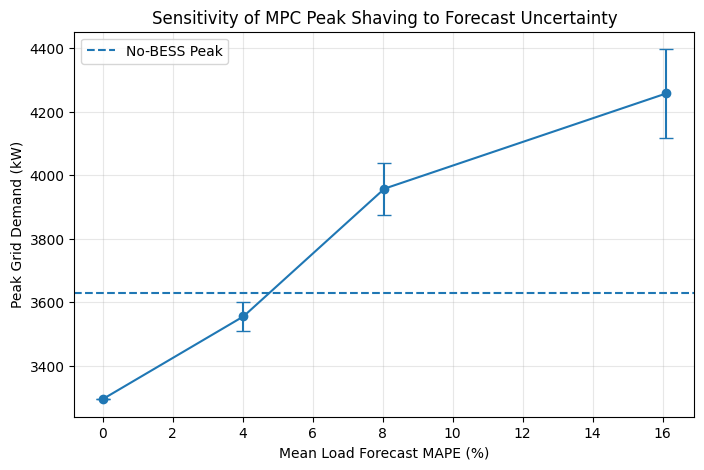

In [ ]:
# Prepare the Monte Carlo results for the final forecast-error versus peak-demand diagnostic plot.
plot_data = mc_summary.copy()

plt.figure(figsize=(8, 5))

plt.errorbar(
    plot_data["Load_MAPE_mean"],
    plot_data["Peak_mean_kW"],
    yerr=plot_data["Peak_std_kW"].fillna(0),
    marker="o",
    capsize=5
)

plt.axhline(
    baseline_peak,
    linestyle="--",
    label="No-BESS Peak"
)

plt.xlabel("Mean Load Forecast MAPE (%)")
plt.ylabel("Peak Grid Demand (kW)")
plt.title(
    "Sensitivity of MPC Peak Shaving "
    "to Forecast Uncertainty"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### One-day diagnostic visualization

One 24-hour period is plotted for each uncertainty level to show the relationship between forecast error, battery action, grid demand, and SOC.

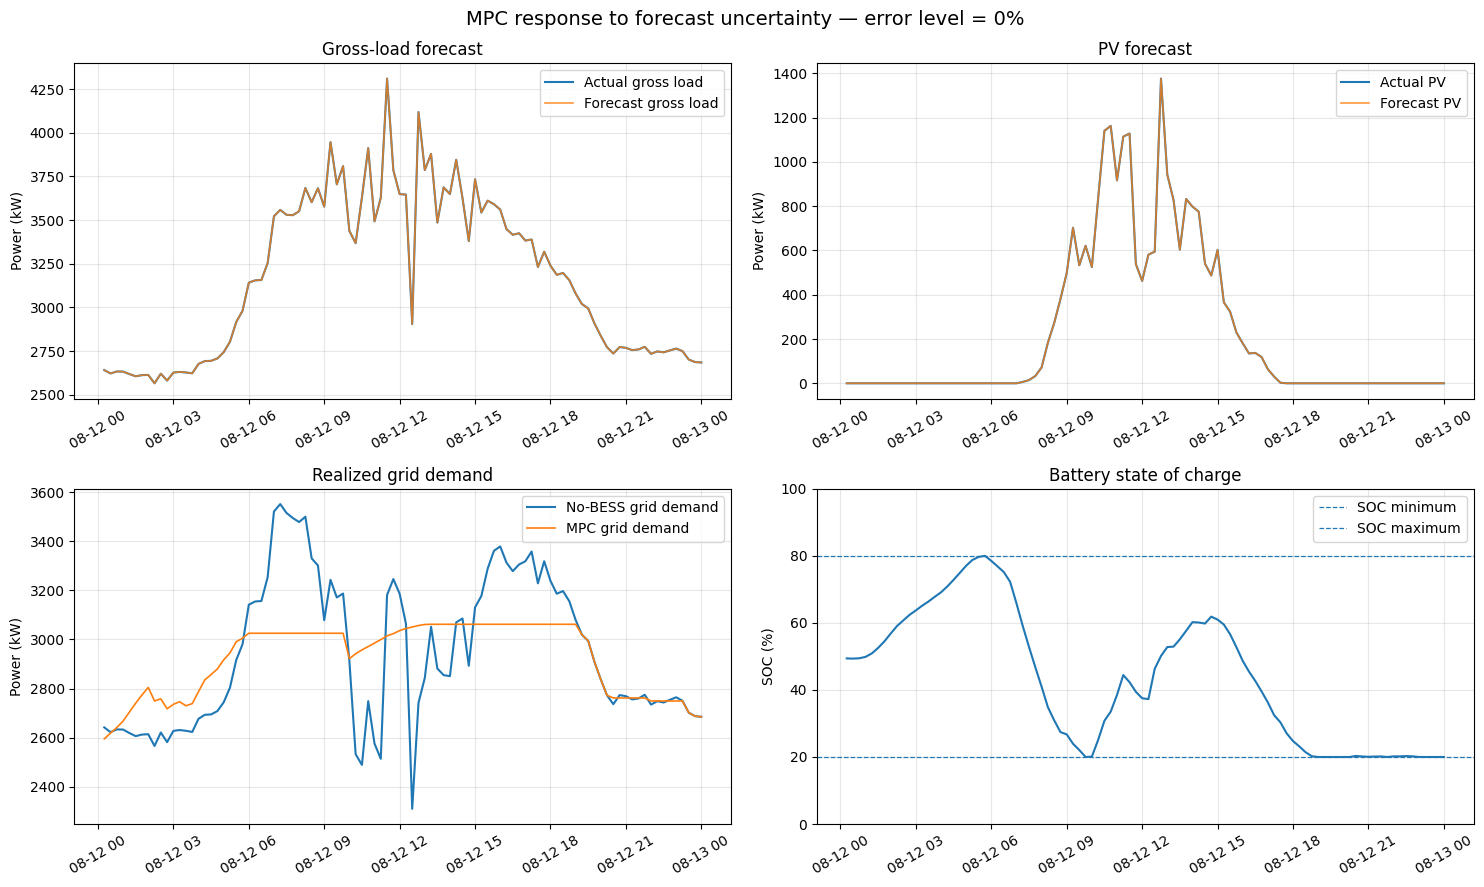

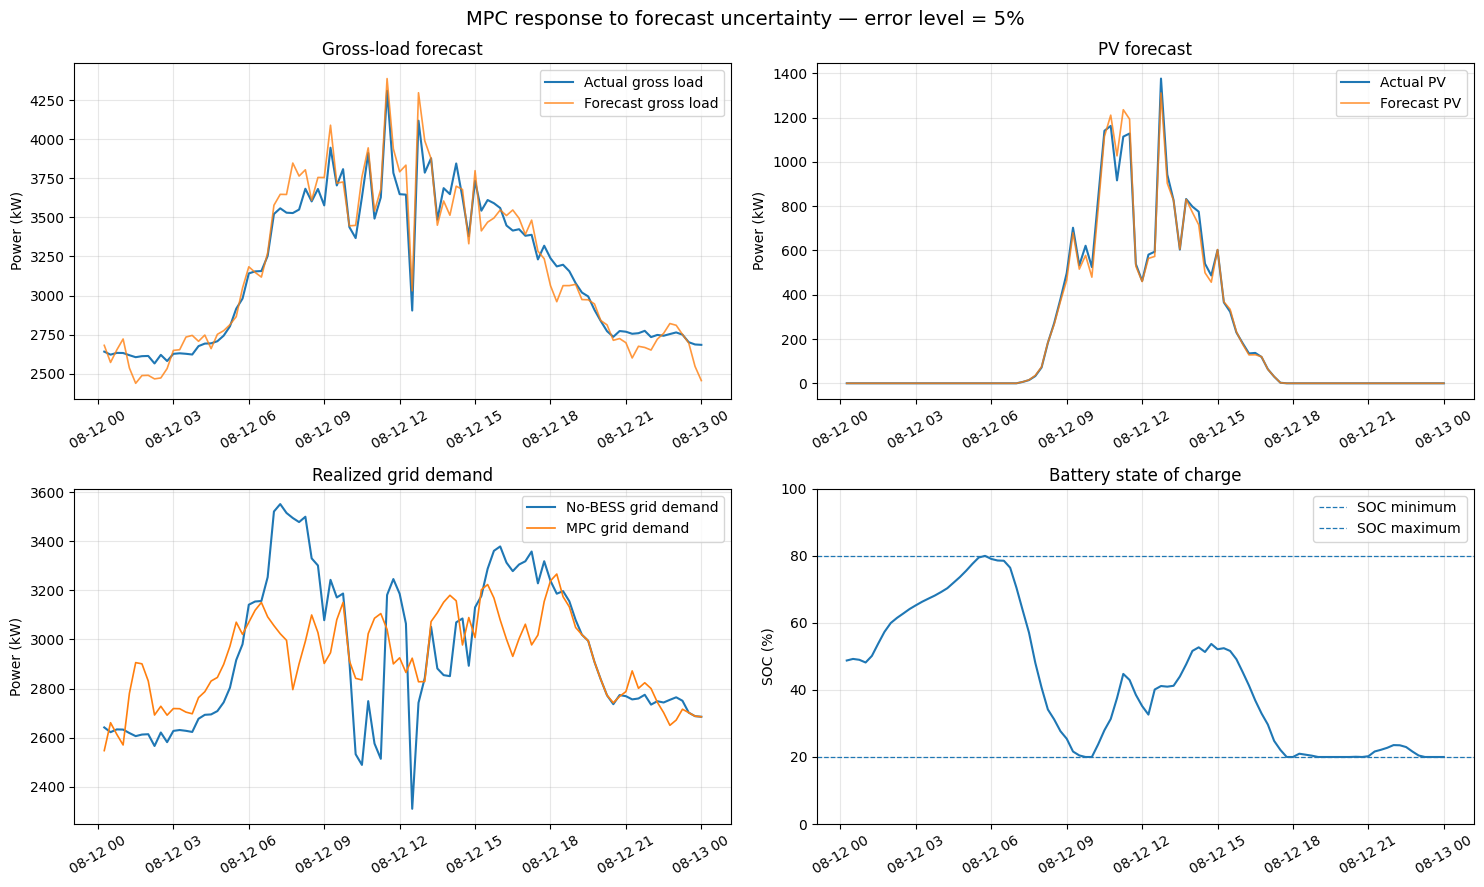

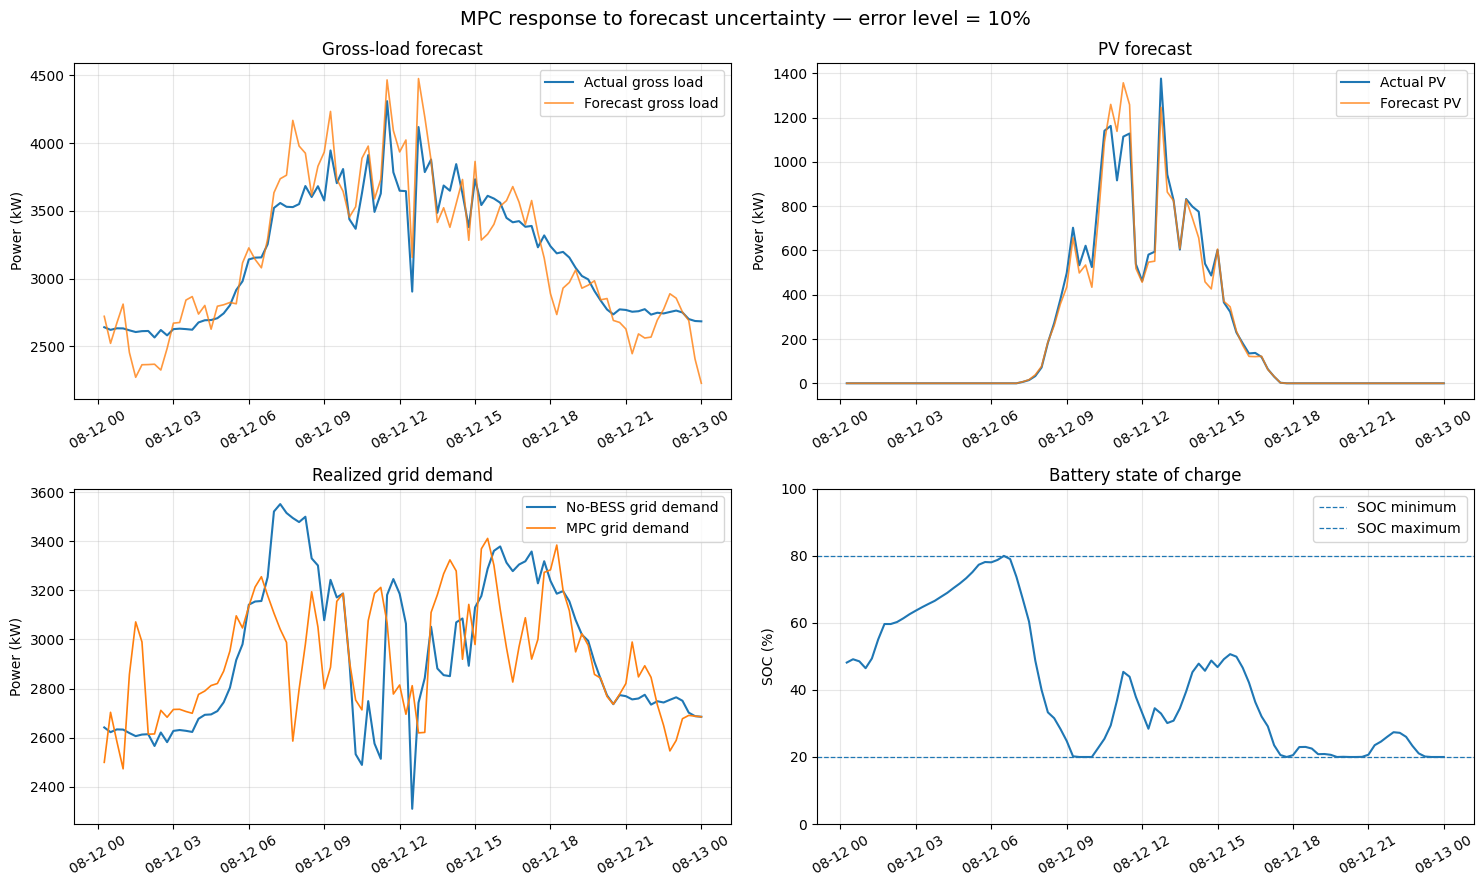

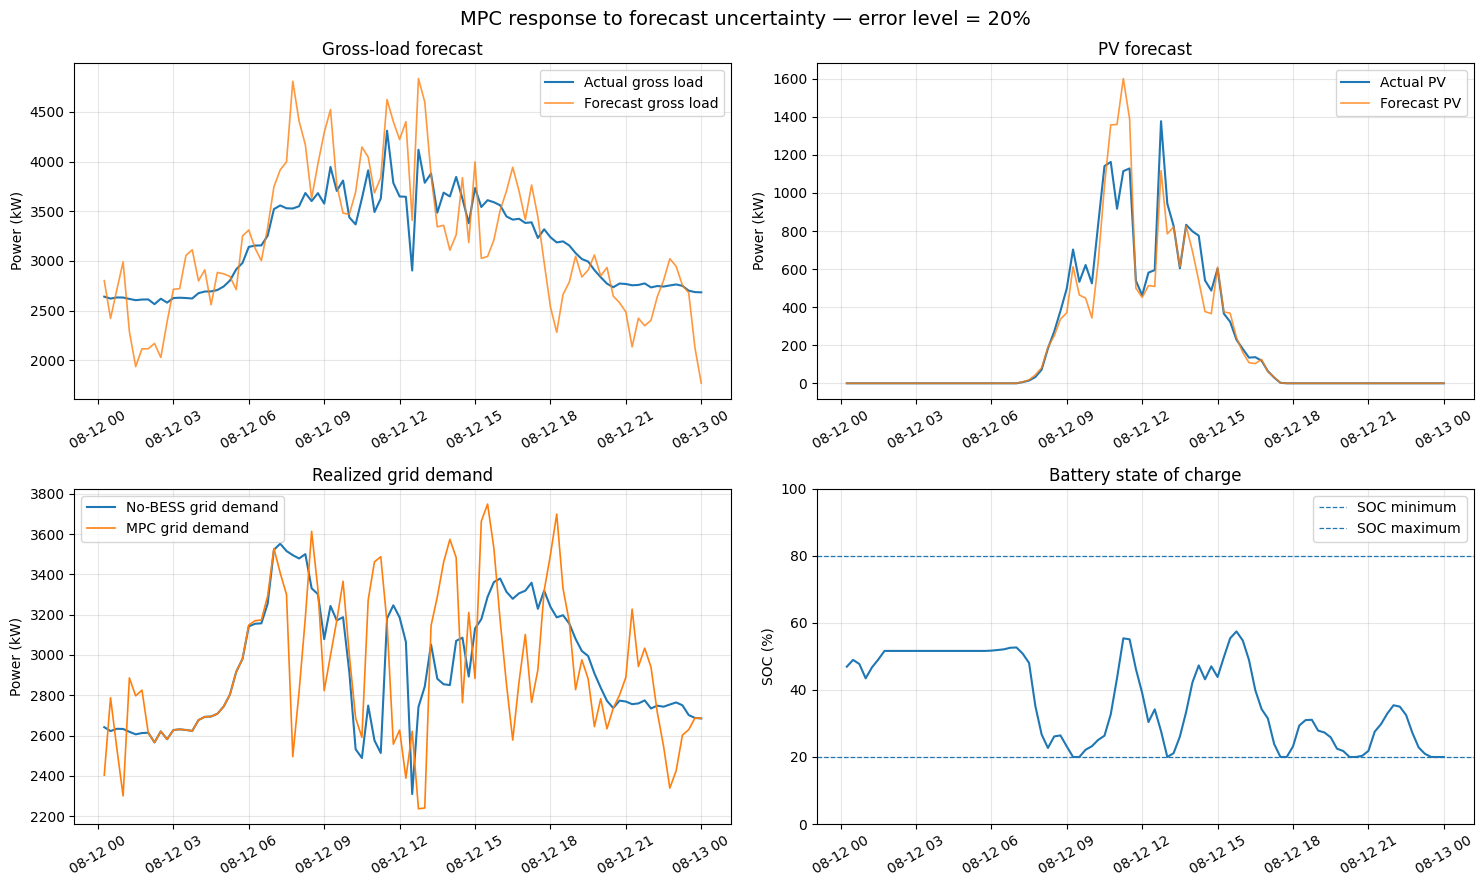

In [ ]:
# ---------------------------------------------------------
# Diagnostic plots for perfect and imperfect forecasts
# One-day comparison
# ---------------------------------------------------------

DIAGNOSTIC_ERROR_LEVELS = [0.00, 0.05, 0.10, 0.20]
DIAGNOSTIC_SEED = 42

# Use only one day: 96 x 15-minute intervals
diagnostic_day = horizon_data.iloc[:96].copy().reset_index(drop=True)

for error_level in DIAGNOSTIC_ERROR_LEVELS:

    if error_level == 0.0:
        # Perfect forecast: measured future values are supplied directly.
        diagnostic_data = diagnostic_day.copy()

        diagnostic_data["Gross_Load_Forecast_kW"] = diagnostic_data[
            "Gross_Load_kW"
        ]

        diagnostic_data["PV_Forecast_kW"] = diagnostic_data[
            "PV_kW"
        ]

        diagnostic_result = run_mpc_controller(
            diagnostic_day,
            horizon=24,
            throughput_weight=0.001
        )

    else:
        diagnostic_data = create_forecast_trajectory(
            diagnostic_day,
            error_level=error_level,
            seed=DIAGNOSTIC_SEED,
            correlation=0.8
        )

        diagnostic_result = run_mpc_with_forecasts(
            diagnostic_data,
            horizon=24,
            throughput_weight=0.001
        )

    # Common 24-hour time axis
    time_axis = diagnostic_data["Timestamp"]

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))

    fig.suptitle(
        f"MPC response to forecast uncertainty — "
        f"error level = {error_level:.0%}",
        fontsize=14
    )

    # -----------------------------------------------------
    # 1. Gross-load forecast
    # -----------------------------------------------------
    axes[0, 0].plot(
        time_axis,
        diagnostic_data["Gross_Load_kW"],
        label="Actual gross load",
        linewidth=1.5
    )

    axes[0, 0].plot(
        time_axis,
        diagnostic_data["Gross_Load_Forecast_kW"],
        label="Forecast gross load",
        linewidth=1.2,
        alpha=0.8
    )

    axes[0, 0].set_title("Gross-load forecast")
    axes[0, 0].set_ylabel("Power (kW)")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # -----------------------------------------------------
    # 2. PV forecast
    # -----------------------------------------------------
    axes[0, 1].plot(
        time_axis,
        diagnostic_data["PV_kW"],
        label="Actual PV",
        linewidth=1.5
    )

    axes[0, 1].plot(
        time_axis,
        diagnostic_data["PV_Forecast_kW"],
        label="Forecast PV",
        linewidth=1.2,
        alpha=0.8
    )

    axes[0, 1].set_title("PV forecast")
    axes[0, 1].set_ylabel("Power (kW)")
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # -----------------------------------------------------
    # 3. Realized grid demand after MPC
    # -----------------------------------------------------
    axes[1, 0].plot(
        time_axis,
        diagnostic_result["Grid_Baseline_kW"],
        label="No-BESS grid demand",
        linewidth=1.5
    )

    axes[1, 0].plot(
        time_axis,
        diagnostic_result["Grid_MPC_kW"],
        label="MPC grid demand",
        linewidth=1.2
    )

    axes[1, 0].set_title("Realized grid demand")
    axes[1, 0].set_ylabel("Power (kW)")
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # -----------------------------------------------------
    # 4. Battery SOC
    # -----------------------------------------------------
    axes[1, 1].plot(
        time_axis,
        diagnostic_result["SOC"] * 100,
        linewidth=1.5
    )

    axes[1, 1].axhline(
        SOC_MIN * 100,
        linestyle="--",
        linewidth=0.9,
        label="SOC minimum"
    )

    axes[1, 1].axhline(
        SOC_MAX * 100,
        linestyle="--",
        linewidth=0.9,
        label="SOC maximum"
    )

    axes[1, 1].set_title("Battery state of charge")
    axes[1, 1].set_ylabel("SOC (%)")
    axes[1, 1].set_ylim(0, 100)
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    # Make timestamps easier to read
    for ax in axes.flat:
        ax.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()


## 16. Conclusions

The study shows how forecast-aware battery scheduling can be built on top of measured campus demand and PV data. Under the perfect-forecast benchmark, the six-hour MPC materially reduces the maximum and upper-tail grid demand compared with both the no-BESS case and the fixed rule-based controller while respecting the specified BESS limits. The horizon experiment shows diminishing improvement beyond six hours for the tested block.

The synthetic forecast experiments also expose an important limitation: deterministic MPC performance deteriorates as forecast errors increase, and sufficiently large errors can make peak demand worse than the no-BESS benchmark. This result is retained rather than hidden because it identifies forecast quality and uncertainty-aware control as important directions for future work.

### Limitations

- The interpretation of NMI demand as net of behind-the-meter PV is a modeling assumption rather than an explicit statement in the datasets.
- PV reconstruction assumes historical site-generation shares remain sufficiently representative when a limited share of sites is missing.
- The 1 MW / 2 MWh BESS is a representative technical configuration, not an economic optimum.
- The controller does not model tariffs, battery degradation cost, export revenue, reactive power, or network constraints.
- The perfect-forecast case is a benchmark; the synthetic-error experiments are controlled sensitivity tests rather than measured operational forecasts.

## References

[1] S. Wimalaratne, D. Haputhanthri, S. Kahawala, G. Gamage, D. Alahakoon, and A. Jennings, “UNISOLAR: An Open Dataset of Photovoltaic Solar Energy Generation in a Large Multi-Campus University Setting,” *2022 15th International Conference on Human System Interaction (HSI)*, pp. 1–5, 2022. doi: 10.1109/HSI55341.2022.9869474.

[2] H. Moraliyage, N. Mills, P. Rathnayake, D. De Silva, and A. Jennings, “UNICON: An Open Dataset of Electricity, Gas and Water Consumption in a Large Multi-Campus University Setting,” *2022 15th International Conference on Human System Interaction (HSI)*, pp. 1–8, 2022. doi: 10.1109/HSI55341.2022.9869498.

[3] H. A. Banawi, M. O. Bahabri, F. A. Hariri, and M. N. Ajour, “Hybrid Wind–Solar–Fuel Cell–Battery Power System with PI Control for Low-Emission Marine Vessels in Saudi Arabia,” *Automation*, vol. 6, no. 4, Art. 69, 2025. doi: 10.3390/automation6040069.

